# Введение

## Цель работы
Изучение алгоритмов кластеризации, приобретение навыков оценки качества разбиения данных на кластеры и интерпретации результатов.

## Постановка задачи

1. Загрузить датасет для задачи кластеризации / классификации (например, с платформы Kaggle). Провести дескриптивный анализ данных: определить размерность, типы признаков, наличие пропусков. Оценить распределение переменных (близость к нормальному) с использованием визуализации (гистограммы). Проверить условие применения кластеризации: отсутствие классов, осмысленность кластеризации, отсутствие выбросов.

2. Выполнить стандартизацию / нормализацию числовых признаков. Обосновать выбор метода масштабирования. Построить матрицу диаграмм рассеивания для визуальной оценки структуры данных, предположительного количества кластеров и типа кластерной структуры. Аргументировать выбор методов кластеризации на основе формы, размера и плотности кластеров.

3. Реализовать кластеризацию двумя различными методами на выбор: K-means (K-средних); иерархическая кластеризация; DBSCAN; EM-алгоритм (Gaussian Mixture). Для методов, требующих задания числа кластеров (K-means, иерархическая), подобрать оптимальное значение k с использованием: метода локтя и / или анализа силуэта.

4. Рассчитать метрики качества для обоих методов: внутренние и внешние. Оценить расстояние между кластерами, внутрикластерные расстояния, компактность кластеров, центры кластеров. Опционально, если известно разделение на классы, посчитать: индекс Rand, индекс Жаккара и др. внешние метрики. Привести содержательную интерпретацию полученных значений.

5. Исследовать влияние параметров одного из методов (например, ε и min_samples для DBSCAN или количества кластеров k для K-means) на качество кластеризации.

6. Визуализировать полученные кластеры в пространстве признаков (использовать PCA для снижения размерности при необходимости). Проанализировать центры кластеров (для K-means) и дать содержательную интерпретацию выделенных групп. Сравнить результаты, полученные двумя разными методами.

# Описание датасета

Для работы выбран датасет [Dry Bean](https://archive.ics.uci.edu/dataset/602/dry+bean+dataset). 

Датасет описывает морфологические признаки семян сухой фасоли 7 сортов, полученные на основе изображений.

С помощью системы компьютерного зрения были получены фотографии 13 611 зёрен фасоли (7 сортов). Из изображений после этапов сегментации и выделения контуров извлечены 16 признаков, описывающих форму и геометрию зерна:
| Признак             | Тип переменной | Описание (рус.)                                                                                    |
| ------------------- | ---------------| -------------------------------------------------------------------------------------------------- |
| **Area**            | целочисленный  | Площадь зерна (количество пикселей внутри контура боба)                                            |
| **Perimeter**       | вещественный   | Периметр зерна — длина границы контура                                                             |
| **MajorAxisLength** | вещественный   | Длина главной оси эллипса, аппроксимирующего зерно (самая длинная линия через зерно)               |
| **MinorAxisLength** | вещественный   | Длина малой оси эллипса (максимальная линия, перпендикулярная главной оси)                         |
| **AspectRatio**     | вещественный   | Отношение 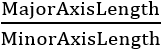 (вытянутость формы)                               |
| **Eccentricity**    | вещественный   | Эксцентриситет эллипса с такими же моментами, как у области зерна                                  |
| **ConvexArea**      | целочисленный  | Площадь выпуклой оболочки: число пикселей в минимальном выпуклом многоугольнике, покрывающем зерно |
| **EquivDiameter**   | вещественный   | Эквивалентный диаметр — диаметр круга с той же площадью, что и зерно                               |
| **Extent**          | вещественный   | Доля площади зерна в его ограничивающем прямоугольнике                                             |
| **Solidity**        | вещественный   | Плотность/выпуклость: 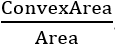                                       |
| **Roundness**       | вещественный   | Округлость: чем ближе к 1, тем форма ближе к кругу. 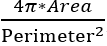         |
| **Compactness**     | вещественный   | Компактность — мера близости формы к кругу: 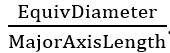                 |
| **ShapeFactor1**    | вещественный   | Фактор формы 1: 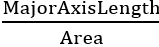                                             |
| **ShapeFactor2**    | вещественный   | Фактор формы 2: 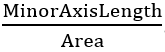                                             |
| **ShapeFactor3**    | вещественный   | Фактор формы 3: 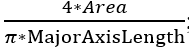                                             |
| **ShapeFactor4**    | вещественный   | Фактор формы 4: 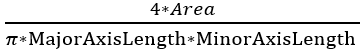                                             |
| **Class**           | категориальный | Сорт фасоли: Seker, Barbunya, Bombay, Cali, Dermosan, Horoz, Sira                                  |

Внешний вид сортов фасоли:

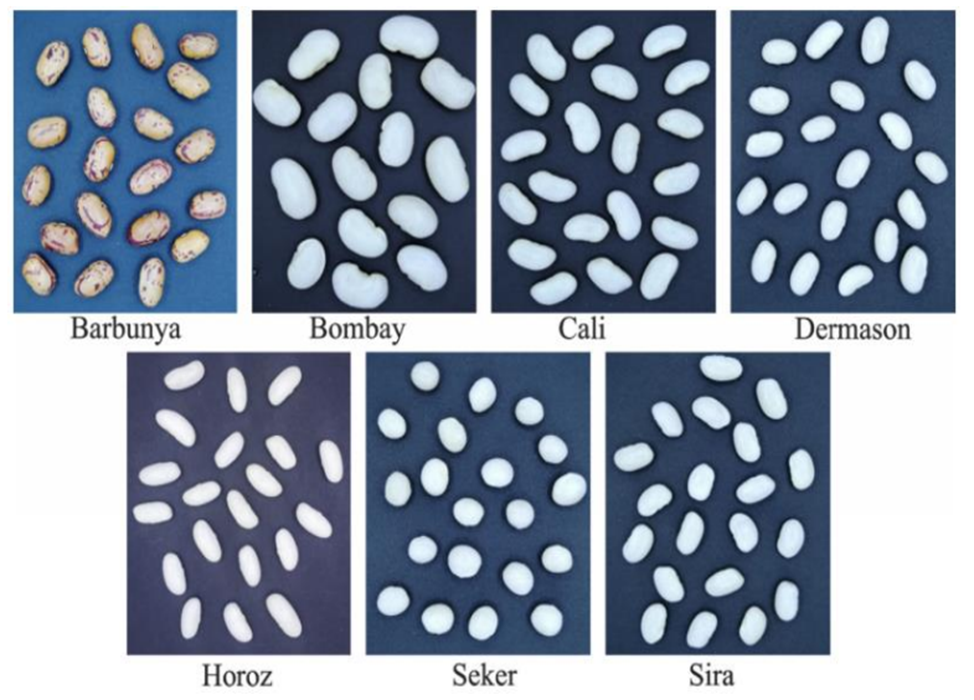

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
import math

df = pd.read_excel("Dry_Bean_Dataset.xlsx")
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


Из датасета мы сразу уберем метку класса - признак Class. Но в конце будем его использовать для анализа полученных результатов.

In [44]:
y = df["Class"]
df = df.drop(columns=["Class"])


missing_per_col = df.isna().sum()
print("\nВсего пропусков в датасете:", missing_per_col.sum())


Всего пропусков в датасете: 0


Как мы видим в датасете отсутвуют пропуски.

# Дескриптивный анализ

,Признак,Среднее,Медиана,Мода,Асимметрия,Эксцесс,Тест Колмагорова-Смирнова
0,Area,53048.28,44652.00,28122.00,2.95,10.80,p=0.000e+00
1,Perimeter,855.28,794.94,683.34,1.63,3.59,p=3.633e-166
2,MajorAxisLength,320.14,296.88,277.37,1.36,2.53,p=1.661e-136
3,MinorAxisLength,202.27,192.43,154.31,2.24,6.65,p=3.647e-287
4,AspectRation,1.58,1.55,1.70,0.58,0.11,p=1.075e-66
5,Eccentricity,0.75,0.76,0.81,-1.06,1.39,p=5.551e-136
6,ConvexArea,53768.20,45178.00,37023.00,2.94,10.74,p=0.000e+00
7,EquivDiameter,253.06,238.44,189.22,1.95,5.19,p=2.368e-182
8,Extent,0.75,0.76,0.59,-0.90,0.64,p=6.026e-81
9,Solidity,0.99,0.99,0.96,-2.55,12.80,p=5.604e-227


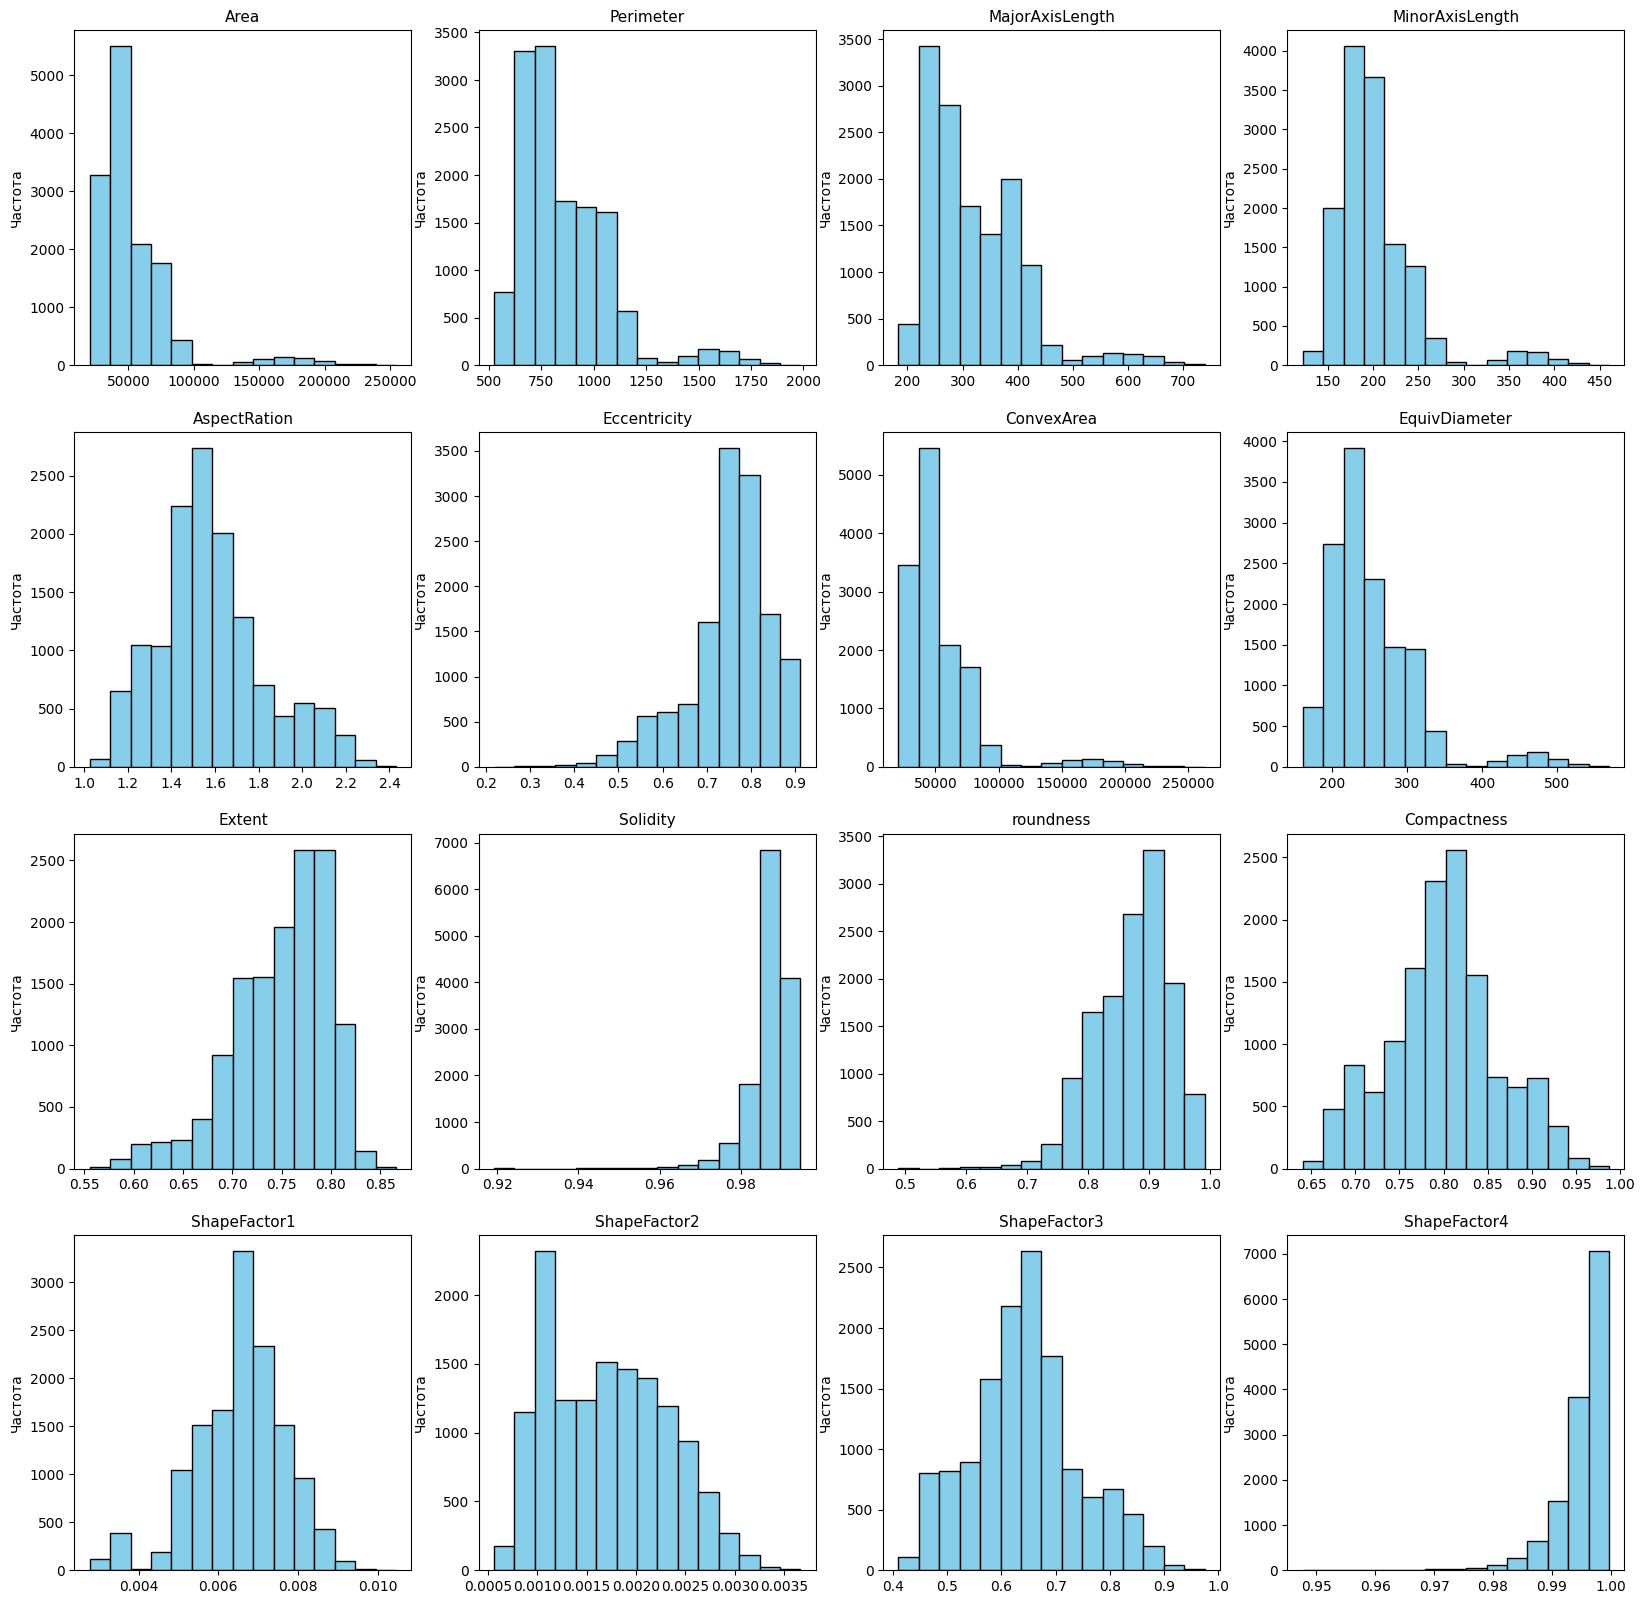

In [45]:
import scipy.stats as stats

n = df.shape[0]
k = int(math.ceil(1 + math.log2(n)))

def interpret_pvalue(p):
     if p > 0.05:
         return "Нормальное"
     elif p > 0.01:
         return "Близко к нормальному"
     else:
         return "Далеко от нормального"
     
features = df.columns
fig, axes = plt.subplots(4, 4, figsize=(20, 20))
axes = axes.flatten()

stat = {
    "Признак": [], "Среднее": [], "Медиана": [], "Мода": [],
    "Асимметрия": [], "Эксцесс": [], "Тест Колмагорова-Смирнова": []
    }

for i, feature in enumerate(features):
    ks_test = stats.kstest(df[feature], 'norm', args=(df[feature].mean(), df[feature].std()))

    stat["Признак"].append(feature)
    stat["Среднее"].append(round(df[feature].mean(), 2))
    stat["Медиана"].append(round(df[feature].median(), 2))
    stat["Мода"].append(round(df[feature].mode()[0], 2))
    stat["Асимметрия"].append(round(df[feature].skew(), 2))
    stat["Эксцесс"].append(round(df[feature].kurtosis(), 2))
    stat["Тест Колмагорова-Смирнова"].append(f"p={ks_test.pvalue:.3e}")


    axes[i].hist(df[feature], bins=k, edgecolor='black', color='skyblue')
    axes[i].set_title(feature, fontsize=11)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Частота")

display(pd.DataFrame(stat))

В результате видим, что ни один из признаков не имеет нормального распределения. Об этом свидетельствуют высокие значения модулей асимметрии и эксцесса, визуальная оценка гистограмм, а также проведенный тест Колмогорова-Смирнова (у всех признаков значение p <0.05). Близкому к нормального распределению можно назвать признаки ShapeFactor3 и Compactness, но они все так же не являются нормальными. 

# Отбор признаков

## Матрица корреляции

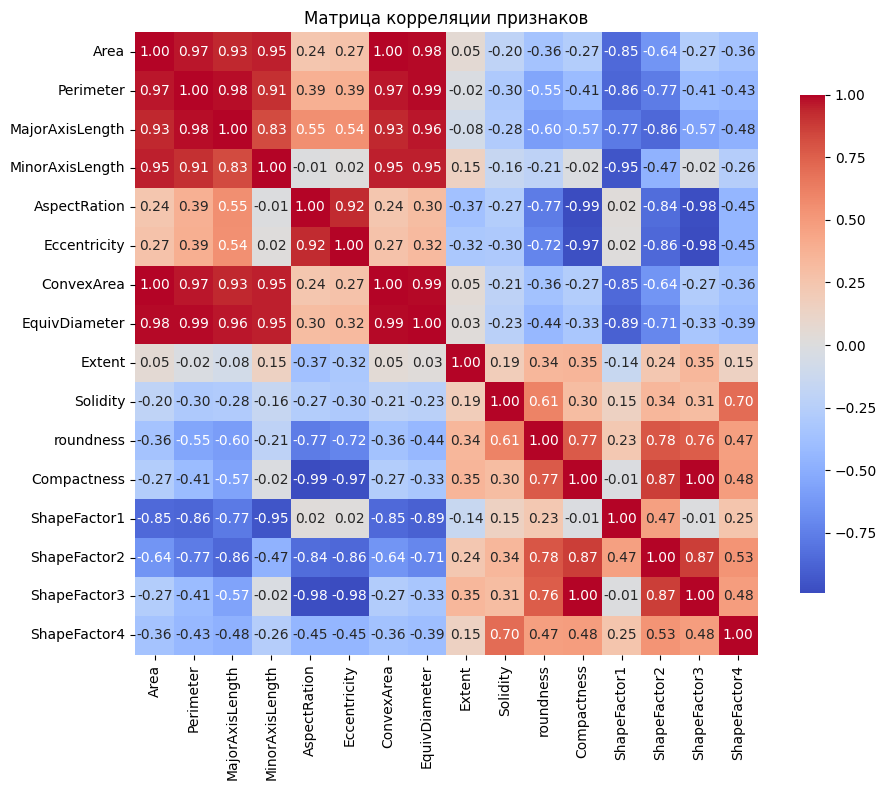

In [46]:
corr = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Матрица корреляции признаков")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Матрица показывает сильные корреляции между признаками, это не удивительно, т.к. признаки описываю либо математические формулы (таблицы 1), либо имеют тривиальные корреляции (например площадь и периметр). Поэтому требуется провести отбор признаков.

Для начала выделим группы коррелирующих признаков:
- Группа 1. Area, Perimeter, MajorAxisLength, MinorAxisLength, ConvexArea, EquivDiameter, ShapeFactor1, ShapeFactor2. Все эти признаки описывают размерность боба или являются отношениями признаков, связанных с размерностью. Из этой группы возьмем MinorAxisLength (длина малой оси эллипса).
- Группа 2. Compactness, ShapeFactor3, AspectRation, Eccentricity. Все эти признаки говорят о округлости/вытянутости формы. По сути, они дублируют друг друга и имеют сильную корреляцию. Логичным будет взять Compactness (компактность — мера близости формы к кругу). 
- Среди оставшихся признаков уберем ShapeFactor4, так как его тяжело интерпретировать. А также roundness, т.к. он имеет сильную корреляцию с Compactness, и имеет тот же самый смысл – показывает округлость формы зерна. 

После отбора признаков получилось выделить 4 наиболее информативных:
1. **Extent** — доля площади зерна в ограничивающем прямоугольнике. Считается как отношение площади зерна к площади минимального прямоугольника, который его полностью содержит.
    - Большой Extent (~1) - форма хорошо «заполняет» прямоугольник (почти прямоугольная или округлая фасоль, без сильной вытянутости и выемок).
    - Малый Extent - зерно либо сильно вытянуто, либо имеет «дырки»/неровные края и занимает лишь часть bounding box.

    Таким образом, Extent отражает, насколько форма рационально использует своё ограничивающее пространство и помогает отличать компактные, «пухлые» зёрна от вытянутых/кривых.
2. **MinorAxisLength** — длина малой оси эллипса, аппроксимирующего зерно (максимальная линия, перпендикулярная главной оси).

    Это, по сути, характерная «ширина» зерна. Описывает размер, но сам по себе даёт хороший индикатор масштаба объектов: мелкие сорта vs крупные.

3. **Solidity** — плотность / выпуклость формы. Это отношение площади зерна к площади его выпуклой оболочки 
    - Solidity близко к 1 - форма почти выпуклая, без глубоких выемок и отверстий.
    - Solidity заметно меньше 1 - у зерна есть «зубчики», вогнутости, оно сильно отличается от выпуклой формы.
    - Признак хорошо ловит неровность контура и отличает гладкие, «правильные» фасолины от более кривых и выемчатых.
4. **Compactness** — компактность, мера близости формы к кругу. Этот признак концентрированно отражает вытянутость / продолговатость фасоли.
    - Если значение близко к 1, фасоль будет почти круглой.
    - Чем значение меньше, тем более фасоль вытянута.

После удаления неинформативных признаков получим следующую матрицу корреляции. 

## Матрица корреляции после отбора признаков

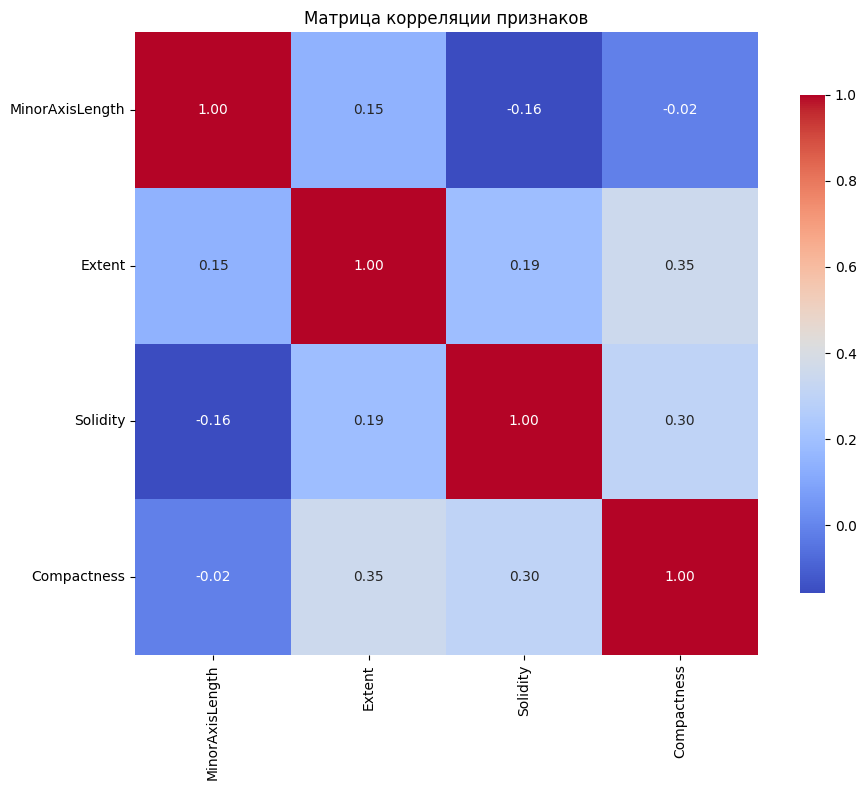

In [47]:
clean_df = df.copy().drop(columns=["Area", "Perimeter", "MajorAxisLength", "ConvexArea", "EquivDiameter", "ShapeFactor1", "ShapeFactor2", "ShapeFactor3", "AspectRation", "Eccentricity", "ShapeFactor4","roundness"])
corr = clean_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Матрица корреляции признаков")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Стандартизация данных

## Диаграммы "Ящик с усами"

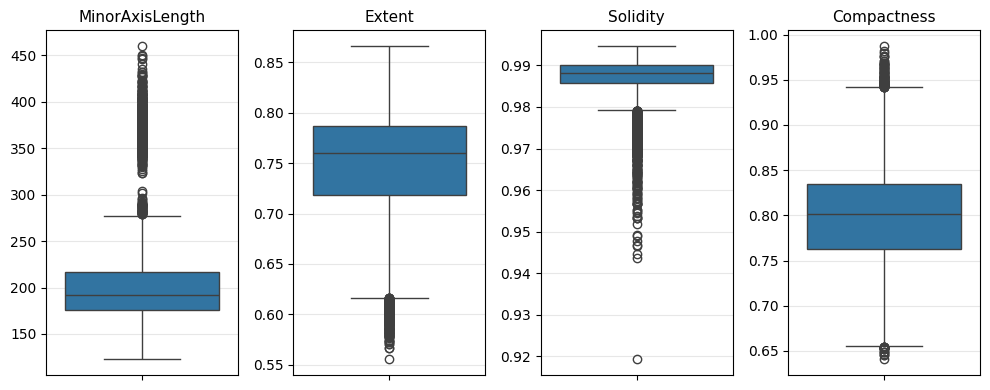

In [48]:
features = clean_df.columns.tolist()
n_features = len(features)

n_cols = 2
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(1, 4, figsize=(10, 4))
axes = axes.flatten()

for i, col in enumerate(features):
    ax = axes[i]
    sns.boxplot(
        y=clean_df[col],
        ax=ax
    )
    ax.set_title(col, fontsize=11)
    ax.set_ylabel("")  
    ax.grid(axis="y", alpha=0.3)

for j in range(n_features, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


На рисунке представлены диаграммы “Ящик с усами”. По ним можно сделать вывод что требуется стандартизация, т.к. значения MinorAxisLength значительно больше, чем значения других признаков. 

Также на рисунке наблюдаем большое количество выбросов, эти выбросы не аномальны (не являются ошибками измерения). 

В связи с этим будем использовать RobustScaler для стандартизации, 

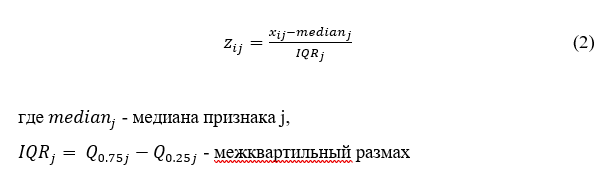


т.к. в отличии от StandardScaler 

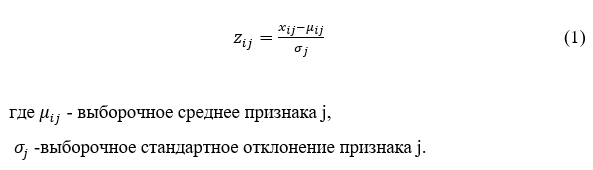

он хорошо справляется с выбросами. Связано это с тем, что StandardScaler использует среднее и стандартное отклонение, которые очень чувствительны к выбросам. 
Для RobustScaler используются медиана и IQR, которые почти не реагируют на выбросы. То есть масштаб задаётся теми наблюдениями, которые находятся внутри ящика, а „усы“ и отдельные точки не ломают масштаб.


## Стандартизация признаков

In [49]:
from sklearn.preprocessing import RobustScaler

X = clean_df.copy()

scaler = RobustScaler()
X_scaled_array = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled_array,
    columns=X.columns,
    index=X.index
)

# Диаграммы рассеивания

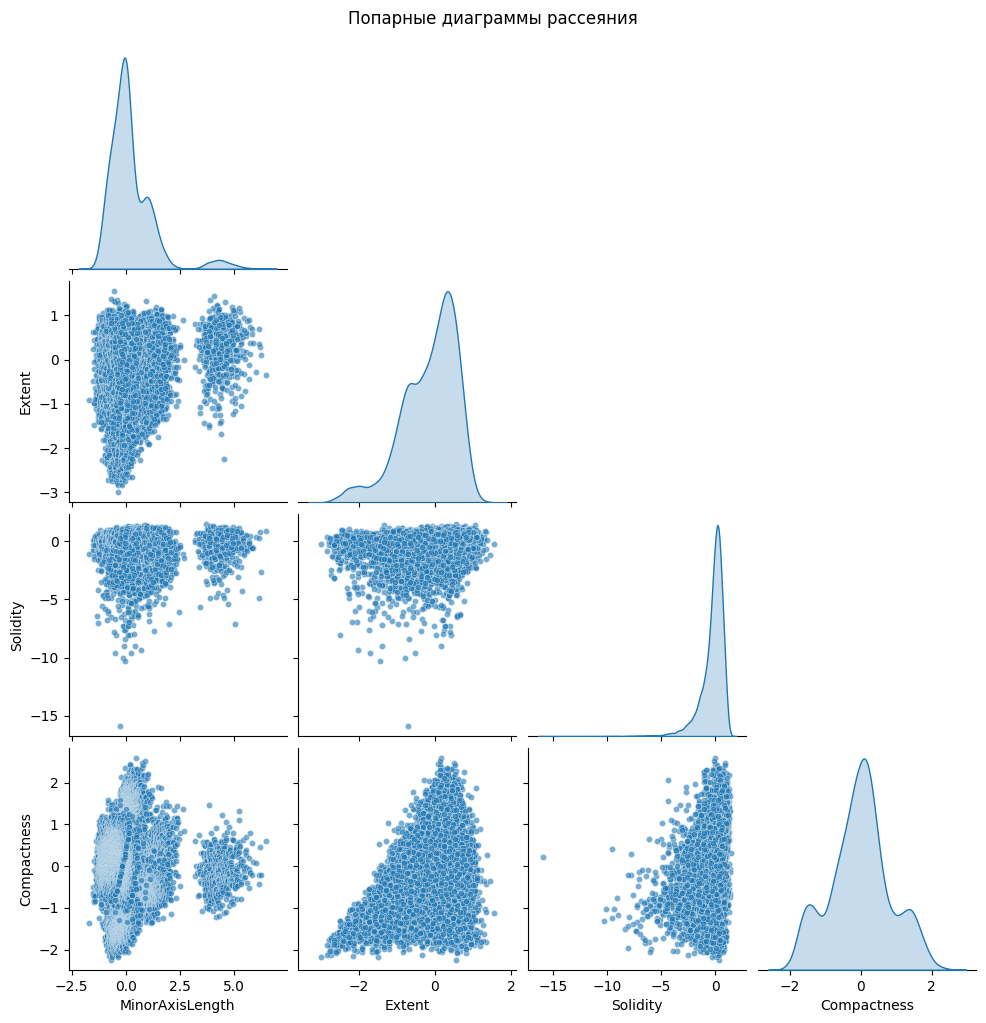

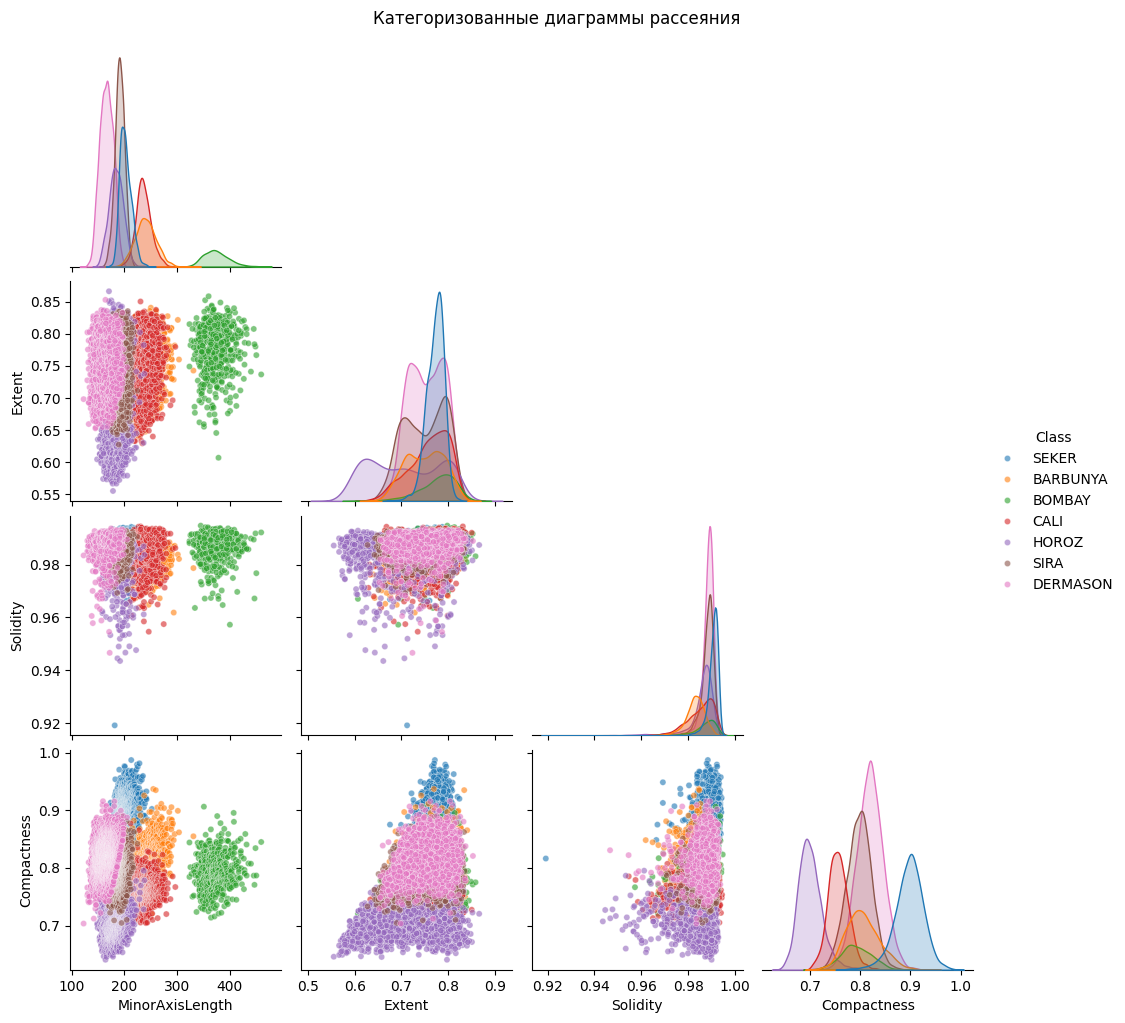

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.pairplot(
    X_scaled,
    vars=X_scaled.columns.tolist(),
    diag_kind="kde",
    corner=True,
    plot_kws={"alpha": 0.6, "s": 20}
)
plt.suptitle("Попарные диаграммы рассеяния", y=1.02)
plt.show()

df_plot = X.copy()
df_plot["Class"] = y.values

sns.pairplot(
    df_plot,
    vars=X_scaled.columns.tolist(),
    hue="Class",
    diag_kind="kde",
    corner=True,
    plot_kws={"alpha": 0.6, "s": 20}
)
plt.suptitle("Категоризованные диаграммы рассеяния", y=1.02)
plt.show()


На первом рисунке представлены диаграммы рассевания признаков, второй рисунок уже показывает распределение классов на диаграммах. Анализируя рисунки, можно прийти к выводам:
- MinorAxisLength разделяет классы лучше всего, сорта фасоли лучше всего отличаются по размеру. 
- Compactness тоже неплохо отделяет сорта, но многие сорта там уже пересекаются. 
- Extent сильно перекрывается, он скорее уточняет класс, нежели определяет его. 
- У Solidity наблюдается уже большое количество перекрытий, почти все значения сосредоточены в небольшом диапазоне.

Если не обращать внимания на классовые метки, то по диаграммам рассеивания MinorAxisLength–Compactness видно 3-5 кластеров, один из которых очень хорошо отделен. 

Оценим тип кластерной структуры. 
- Сами по себе кластеры компактные, по форме ближе к эллипсу. 
- Между ними наблюдается сильное перекрытие (сорта фасоли похожи друг на друга по форме и размеру, кроме одного, который больше остальных). 
- Нет ярко выраженной иерархии, но можно увидеть укрупнённые семейства сортов (2–4 больших группы), внутри которых находятся отдельные сорта. 
- Нет ярко выраженного шума. 

В связи с эти для кластерного анализа выбраны следующие методы:
- **GMM**, так как он хорошо справляется с перекрывающимися кластерами и кластерами эллиптической формы.
- **K** – средних, как базовый метод кластеризации

Не берем не рассмотрение следующие методы:
- **Иерархическая кластеризация**, так как нет выраженной иерархии в данных
- **DBSCAN**, так как этот метод больше подходит для данных с чёткими плотными областями и разреженными промежутками, наши данные больше похожи на облако с внутренней структурой. 


# GMM (Generalized Method of Moments)

## Определение параметров метода

### Тип ковариационной матрицы. 
В среде разработки представлены следующие реализации:

- full – полная ковариация для каждого кластера (эллипсы любой формы);
- tied – одна общая ковариационная матрица для всех компонент;
- diag – диагональные ковариации (эллипсы без наклона, признаки некоррелированы внутри кластера);
- spherical – ковариации пропорциональны единичной матрице

Для реализации берем full, т.к. по диаграммам рассевания ранее уже определили, что кластера эллипсоидной (не шарообразной формы), при этом формы и разброс имеют различия. 

### Количество кластеров
Для определения лучшего количества кластеров будем сравнивать значения метрик для k от 2 до 9. 


Метрики GMM для разных k:


,k,silhouette,calinski_harabasz,davies_bouldin,ARI,log_likelihood,AIC,BIC
0,2,0.3277,4613.2879,1.4718,0.1790,-62270.9879,124599.9759,124818.0163
1,3,0.2747,3739.1213,1.7545,0.3095,-59379.2457,118846.4914,119177.3112
2,4,0.2212,3474.4589,1.4993,0.4685,-57097.8647,114313.7295,114757.3289
3,5,0.2687,4365.2909,1.1542,0.5285,-55892.4926,111932.9853,112489.3642
4,6,0.2808,4398.1972,1.1990,0.5464,-55004.5718,110187.1435,110856.3019
5,7,0.2858,4416.1303,1.1849,0.5115,-54744.3450,109696.6901,110478.6280
6,8,0.2558,4387.6979,1.2505,0.4476,-53882.0082,108002.0164,108896.7338
7,9,0.2794,4632.7886,1.1546,0.4137,-53596.5888,107461.1777,108468.6746


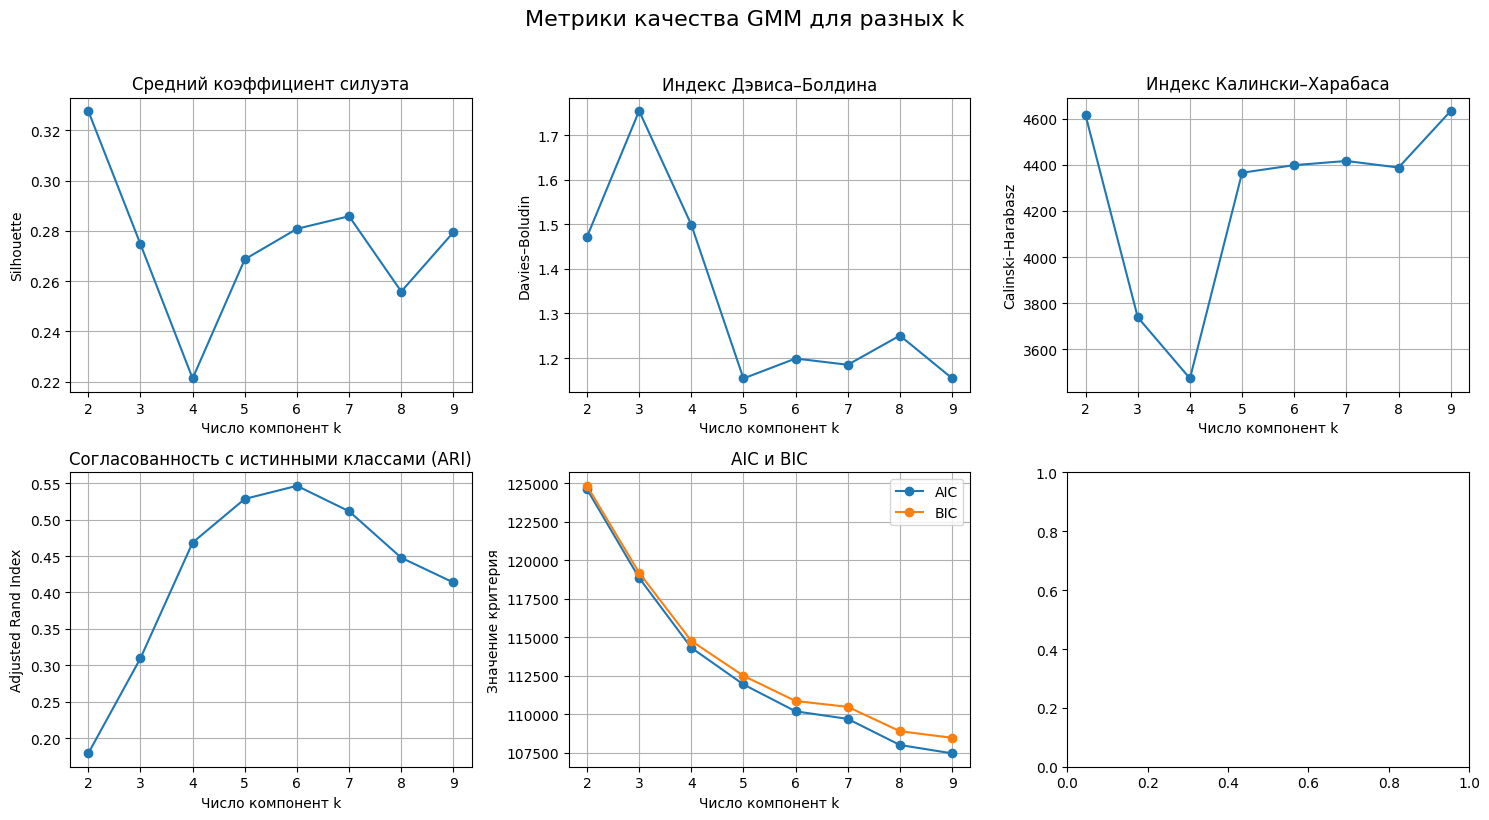

In [51]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
)

k_range = range(2, 10) 

rows = []

for k in k_range:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=42,
        n_init=5,
        init_params="kmeans",
    )
    gmm.fit(X_scaled)
    labels = gmm.predict(X_scaled)

    sil = silhouette_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)
    ari = adjusted_rand_score(y, labels)

    log_likelihood = gmm.score(X_scaled) * X_scaled.shape[0]
    aic = gmm.aic(X_scaled)
    bic = gmm.bic(X_scaled)

    rows.append({
        "k": k,
        "silhouette": sil,
        "calinski_harabasz": ch,
        "davies_bouldin": db,
        "ARI": ari,
        "log_likelihood": log_likelihood,
        "AIC": aic,
        "BIC": bic,
    })

results = pd.DataFrame(rows)
print("Метрики GMM для разных k:")
display(results.round(4))

res = results.sort_values("k")
k = res["k"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

# 1) Silhouette
axes[0].plot(k, res["silhouette"], marker="o")
axes[0].set_xlabel("Число компонент k")
axes[0].set_ylabel("Silhouette")
axes[0].set_title("Средний коэффициент силуэта")
axes[0].grid(True)

# 2) ARI
axes[3].plot(k, res["ARI"], marker="o")
axes[3].set_xlabel("Число компонент k")
axes[3].set_ylabel("Adjusted Rand Index")
axes[3].set_title("Согласованность с истинными классами (ARI)")
axes[3].grid(True)

# 3) Calinski–Harabasz
axes[2].plot(k, res["calinski_harabasz"], marker="o")
axes[2].set_xlabel("Число компонент k")
axes[2].set_ylabel("Calinski–Harabasz")
axes[2].set_title("Индекс Калински–Харабаса")
axes[2].grid(True)

# 4) Davies–Bouldin
axes[1].plot(k, res["davies_bouldin"], marker="o")
axes[1].set_xlabel("Число компонент k")
axes[1].set_ylabel("Davies–Boludin")
axes[1].set_title("Индекс Дэвиса–Болдина")
axes[1].grid(True)

# 5) AIC и BIC
axes[4].plot(k, res["AIC"], marker="o", label="AIC")
axes[4].plot(k, res["BIC"], marker="o", label="BIC")
axes[4].set_xlabel("Число компонент k")
axes[4].set_ylabel("Значение критерия")
axes[4].set_title("AIC и BIC")
axes[4].legend()
axes[4].grid(True)



plt.suptitle("Метрики качества GMM для разных k", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


Для определения лучшего количества кластеров будем сравнивать как внешние, так и внутренние метрики для k от 2 до 14. 

1. На левом верхнем рисунке представлен график среднего силуэта. Коэффициент силуэта – метрика качества кластеризации, которая одновременно учитывает компактность кластера и разделенность между кластерами. По своей сути она показывает,     насколько хорошо объект принадлежит своему кластеру и насколько далёк от других кластеров.

    Значение этого коэффициента ∈ [-1, 1]:
    - близко к 1 - объект хорошо вписывается в свой кластер и далёк от соседних;
    - около 0 - объект расположен между кластерами;
    - меньше 0 - объект ближе к чужому кластеру, чем к своему (плохая кластеризация).

    Коэффициент силуэта для объекта рассчитывается по формуле ниже. Расчёт среднего коэффициента очевиден.

    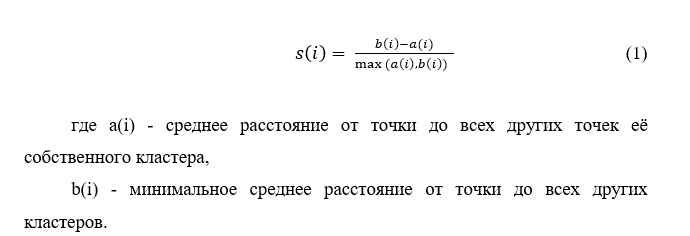

    По диаграмме рассеивания уже можно предположить, что коэффициент не будет слишком высокий из-за достаточно большего b(i), т.к. почти все наши кластеры находятся близко/накладываются друг на друга. Рисунок 10 это подтверждает. При чем   максимальное значение достигается при k = 2. Вероятно это связано с тем, то, что метод выделил 2 кластера в виде большого и малого облака на диаграммах рассеивания (см. рисунок 8). Но такое разбиение слишком грубое, нельзя полностью  опираться на средний коэффициент силуэта. Следующие по величине значения находятся в районе 6-7 кластеров, а также 10.

2. Теперь рассмотрим графики изображённые на нижних рисунках. Слева изображен график индекса Калински–Харабаса. Рассчитывается по формуле:

    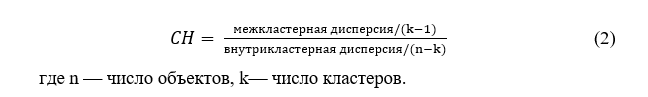

    По сути, чем больше значение этого индекса, там лучше. Но стоит помнить, что индекс склонен “преувеличивать” k, т.к. внутрикластерная дисперсия падает при дроблении. 
    Такую картину мы как раз и наблюдаем на рисунке. Самые большие значения находятся в районе 9 – 10 и 2 (тут аналогично силуэту). Чуть ниже идут значения в диапазоне k = 5 – 8.

3. Справа представлен другой график, индекса Дэвиса–Болдина. Расчёт этого значения производится по формулам 3 - 5.

    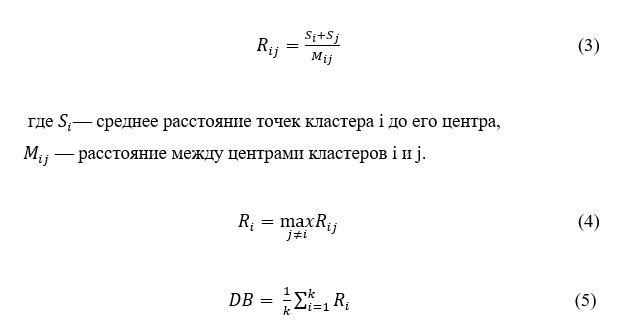

    По своей сути показывает, насколько кластер «похож» на наиболее похожий соседний. Т.е. чем меньше значение этого индекса – тем лучше. Близко к 0 значение – очень хорошее разбиение, близкое к 1 – кластеры пересекаются.
    В нашем случае лучшие значения при k = 5, 9, 10. Чуть хуже 6 – 7.

4. Следующим для рассмотрения будет график, изображенный на рисунке справа сверху. ARI – внешняя метрика (т.е. для расчёта используются значения истинных классов). Для расчёта используются все пары точек данных в данных (формула 6 - Rand Index). Расчёт самого индекса – формула 7.

    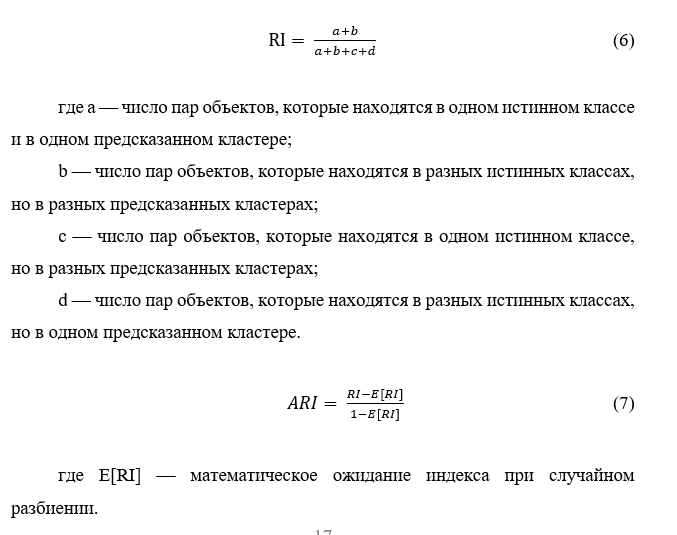

    По сути, эта метрика отображает, насколько полученная кластеризация совпадает с истинными метками классов, при этом учитывает случайное совпадение. Значения от -1 до 1, где 0 – случайное разбиение, 1 – полное совпадение кластеров и истинных классов, <0 – хуже случайного распределения.

    График показывает лучшее значение при k = 6 (0.55). Близкие значения – 5 и 7 (0.5) тоже дают неплохие значения. Отметим, что худшее значение этой метрики при k = 2. При k> 8 значения практически не отличается. 

5. Последним посмотрим на графики BIC и AIC 
AIC и BIC - информационные критерии, которые показывают насколько модель подходит данным и насколько она сложная. BIC сильнее штрафует за сложность, чем AIC.

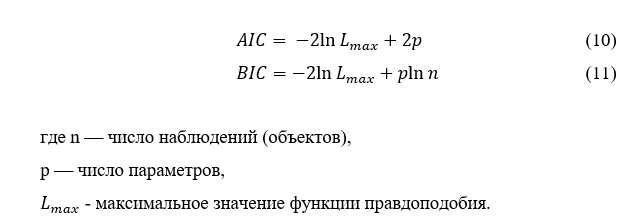

Выбор количества кластеров по этим параметрам производится методом локтя. На рисунке 13 видим локоть в точке k = 5.

Проведя анализ метрик, можем прийти к следующим значениям кол-ва кластеров:

- k = 2 – высокие значения среднего силуэта и индекса Калински–Харабаса. 
- k = 5 – самое низкое значение индекса Дэвиса–Болдина.
- k = 6 – самое высокое значение ARI.
- k = 7 – неплохие метрики, лучшие силуэт после k = 2.

Выберем из этих значений одно. Для каждого ранее выбранного k посмотрим визуальное распределение классов и кластеров, выберем самое интерпретируемое распределение и рассмотрим его подробнее. 
Для визуализации используем диаграмму распределения для двух главных компонент, а также матрицу распределения классов по кластерам. 



### Функция для решения

In [52]:
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA


def calc_gmm(k):
    # Обучаем GMM и получаем метки кластеров
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=42,
        n_init=5,
        init_params="kmeans",
    ).fit(X_scaled)
    labels = gmm.predict(X_scaled)

    X_pca = PCA(n_components=2, random_state=42).fit_transform(X_scaled)

    y_codes, y_classes = pd.factorize(y)

    cm_counts = pd.crosstab(
        pd.Series(y, name="class"),
        pd.Series(labels, name="cluster"),
    )
    cm = cm_counts.div(cm_counts.sum(axis=1), axis=0)

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

    # Истинные классы 
    sc1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=y_codes, s=20, alpha=0.8)
    ax1.set_title("Истинные классы")
    ax1.set_xlabel("PC1")
    ax1.set_ylabel("PC2")
    handles1, _ = sc1.legend_elements()
    ax1.legend(handles1, y_classes.astype(str),
               title="класс", loc="best")

    # Кластеры GMM 
    sc2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=labels, s=20, alpha=0.8)
    ax2.set_title(f"GMM, k={k}")
    ax2.set_xlabel("PC1")
    ax2.set_ylabel("PC2")
    handles2, _ = sc2.legend_elements()
    ax2.legend(handles2, np.unique(labels),
               title="кластер", loc="best")

    # Heatmap: распределение классов по кластерам (доли) 
    im = ax3.imshow(cm.values, vmin=0, vmax=1, aspect="auto")
    ax3.set_title("Распределение классов по кластерам (доля)")
    ax3.set_xlabel("кластер")
    ax3.set_ylabel("класс")

    ax3.set_xticks(np.arange(cm.shape[1]))
    ax3.set_yticks(np.arange(cm.shape[0]))
    ax3.set_xticklabels(cm.columns)
    ax3.set_yticklabels(cm.index)

    for (i, j), v in np.ndenumerate(cm.values):
        ax3.text(j, i, f"{v:.2f}", ha="center", va="center")

    fig.colorbar(im, ax=ax3, fraction=0.046, pad=0.04, label="доля")

    plt.tight_layout()
    plt.show()


### Решение

По своей сути каждое значение лучше по каким-либо критериям. Постараемся выбрать наиболее интерпретируемое.

Для каждого ранее выбранного k посмотрим визуальное распределение классов и кластеров, выберем самое интерпретируемое распределение и рассмотрим его подробнее. 

Для визуализации используем диаграмму распределения для двух главных компонент, а также матрицу распределения классов по кластерам  

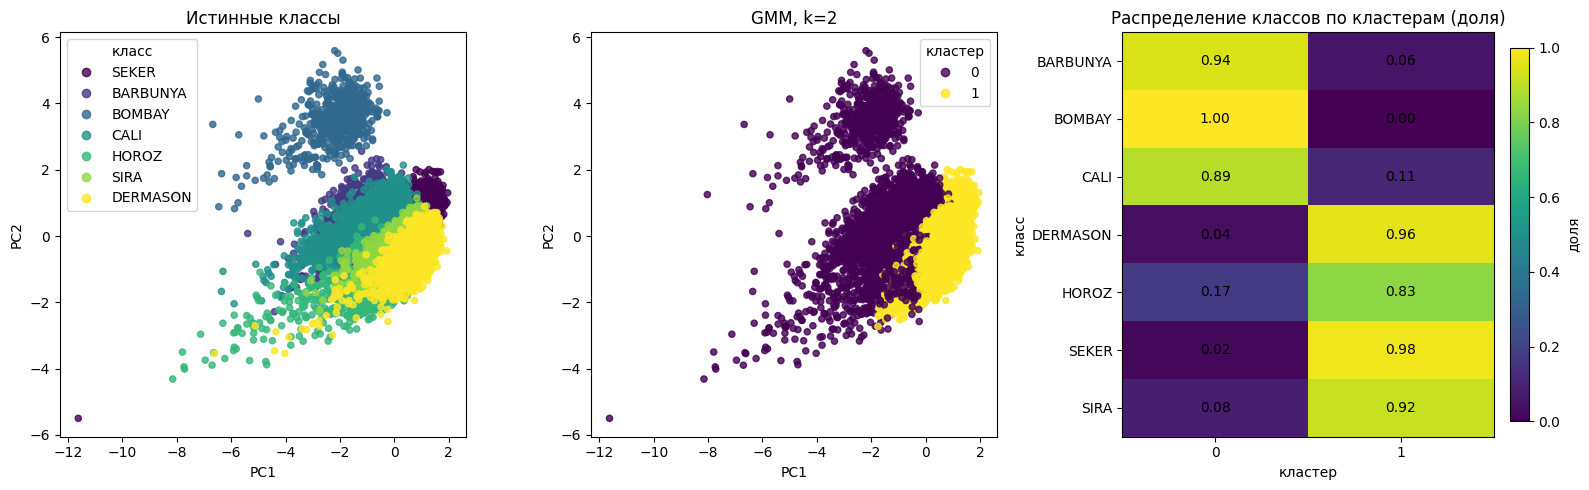

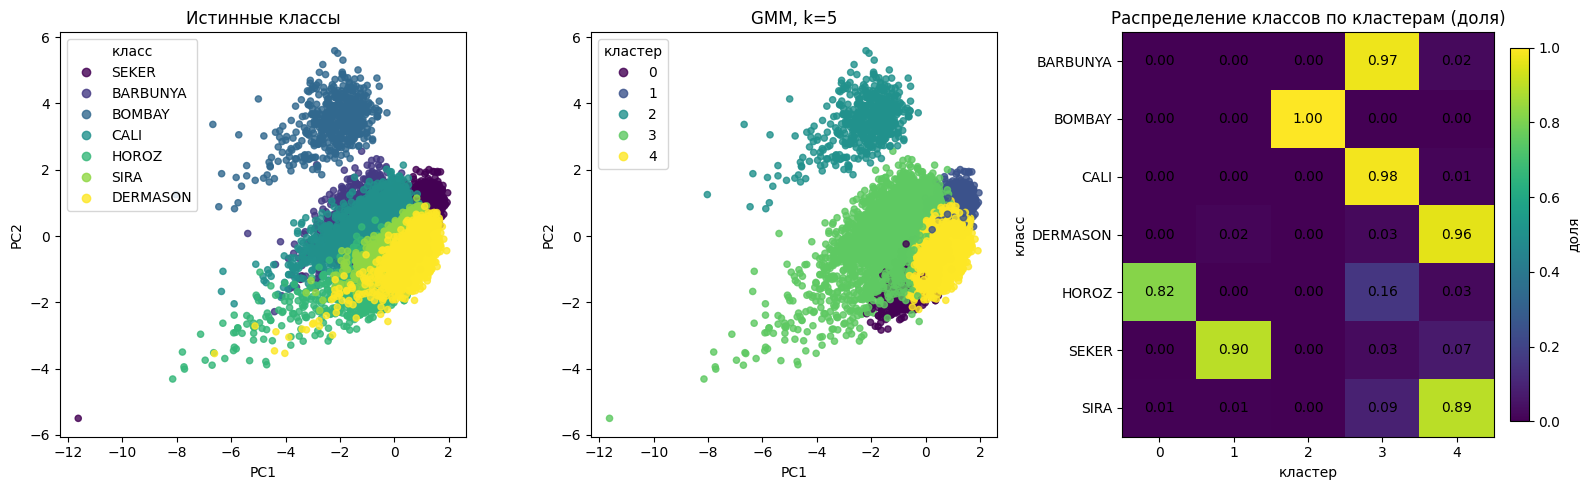

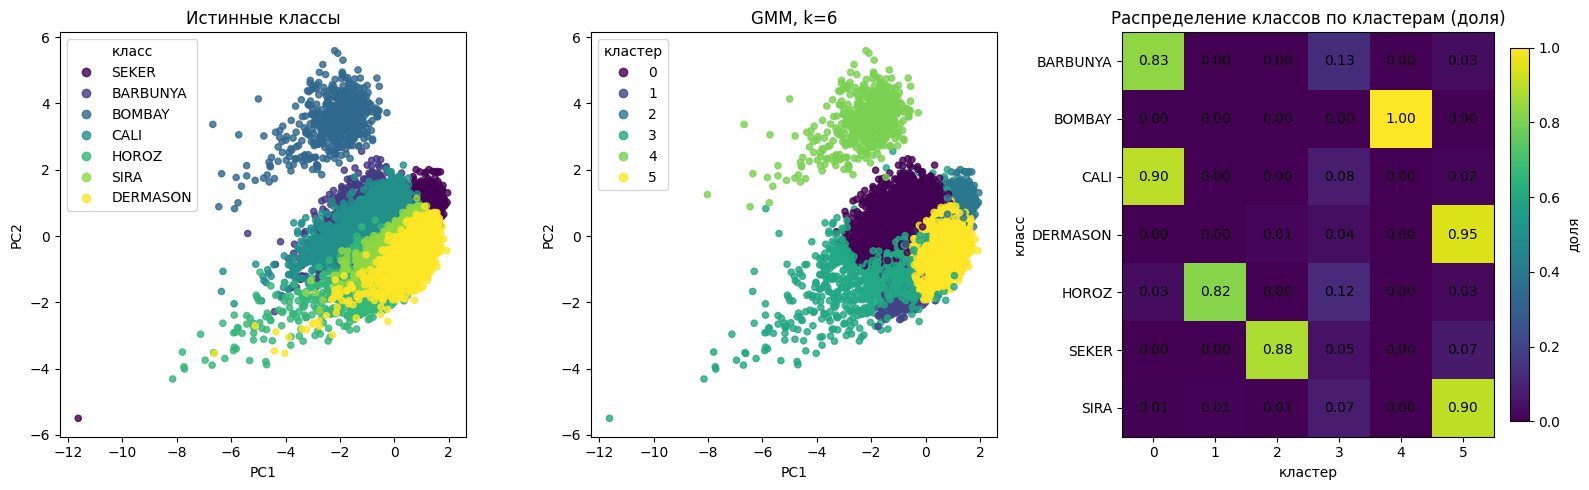

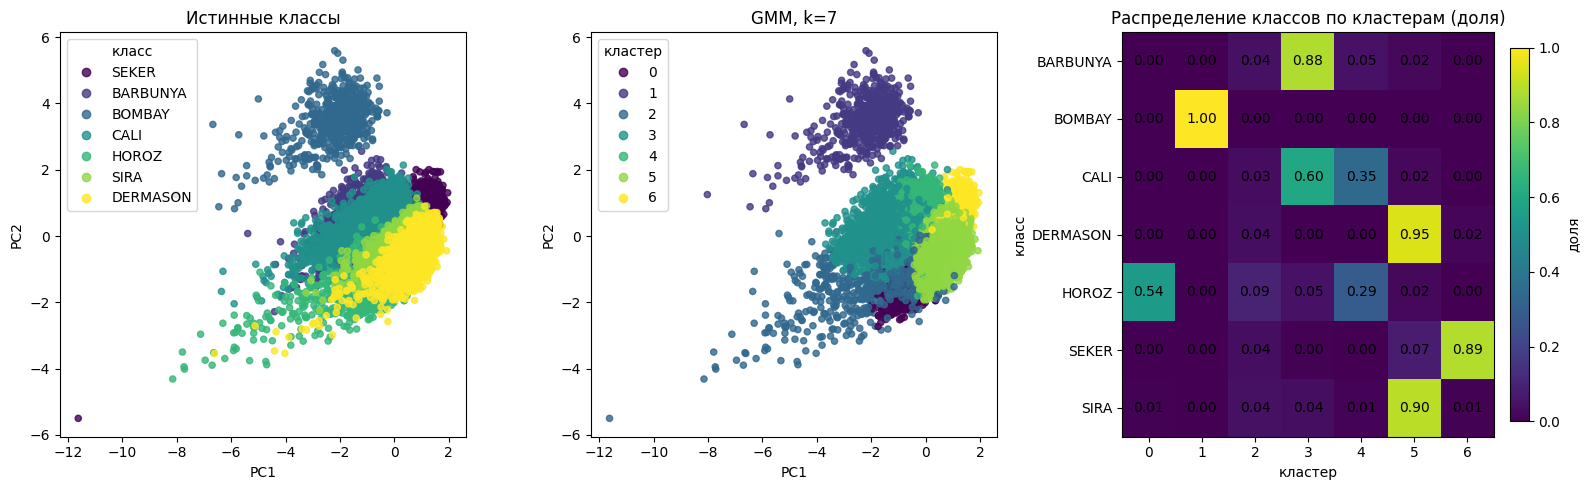

In [53]:
calc_gmm(k=2)
calc_gmm(k=5)
calc_gmm(k=6)
calc_gmm(k=7)

- При k = 2 разбиение получается очень грубым, но при этом видно очень хорошее отделение 3-х и 4-х сортов друг от друга.
- При k = 5 получается наиболее удачное разбиение. Каждый кластер содержит 1 – 2 сорта. 
- При k = 6 уже видим ухудшение, появляется промежуточный кластер, который не дает никакой информации. 
- При k = 7 “доминирование” сортов в кластерах уменьшается.

Наиболее интерпретируемым получилось разбиение при k = 5. 

Метрики GMM (k = 5):
Средний силуэт           : 0.2687
Индекс Калински–Харабаса : 4365.2909
Индекс Дэвиса–Болдина    : 1.1542
ARI                      : 0.5285


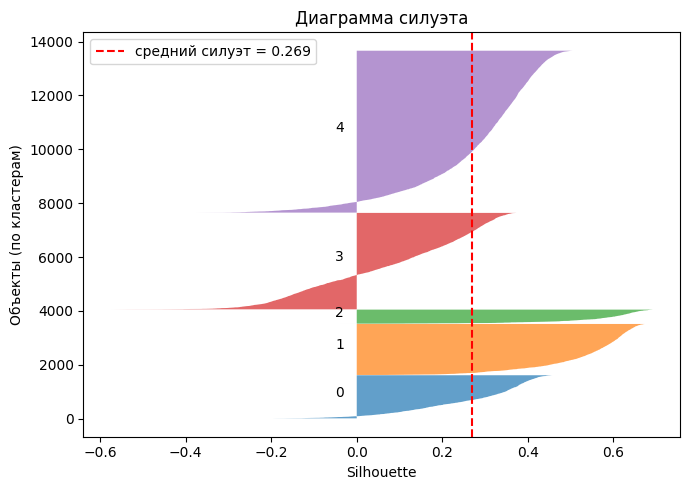


Центры кластеров (в пространстве стандартизованных признаков):


,MinorAxisLength,Extent,Solidity,Compactness
cluster_0,-0.236582,-0.838341,-0.225606,-1.464719
cluster_1,0.217331,0.194266,0.550281,1.383775
cluster_2,4.416419,0.244206,-0.320810,-0.119677
cluster_3,0.868364,-0.143440,-1.225915,-0.347879
cluster_4,-0.380471,-0.111779,0.066675,0.128788


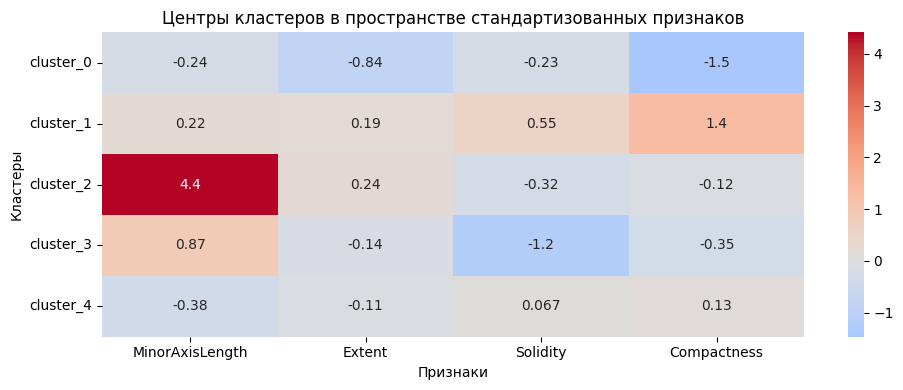


Характеристики кластеров (внутрикластерные расстояния / компактность):


,cluster,size,mean_dist_to_center,std_dist_to_center,within_cluster_SSE
0,0,1601,1.224317,0.465223,2746.330117
1,1,1894,0.589398,0.247911,774.360853
2,2,523,1.295740,0.758237,1178.771015
3,3,3581,1.554928,0.917700,11673.966600
4,4,6012,0.873985,0.289105,5094.762242



Расстояния между центрами кластеров (евклидовы):


,cluster_0,cluster_1,cluster_2,cluster_3,cluster_4
cluster_0,0.000000,3.160417,4.963922,1.987899,1.781373
cluster_1,3.160417,0.000000,4.544667,2.586771,1.503296
cluster_2,4.963922,4.544667,0.000000,3.689208,4.832055
cluster_3,1.987899,2.586771,3.689208,0.000000,1.859729
cluster_4,1.781373,1.503296,4.832055,1.859729,0.000000


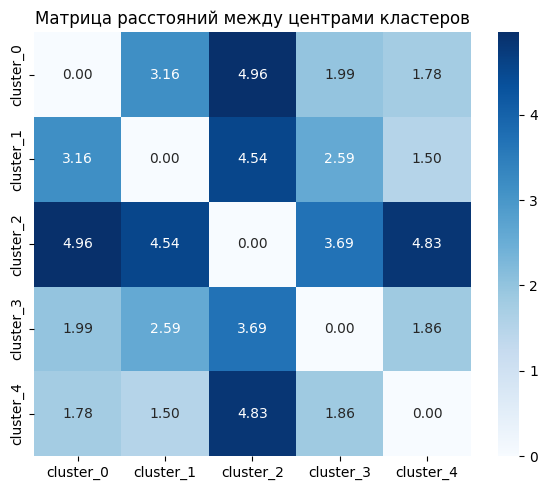


Значимость признаков по кластерам (односторонний ANOVA):


,feature,F_stat,p_value
0,MinorAxisLength,16083.921487,0.0
1,Extent,600.203452,0.0
2,Solidity,1811.043100,0.0
3,Compactness,10788.257578,0.0


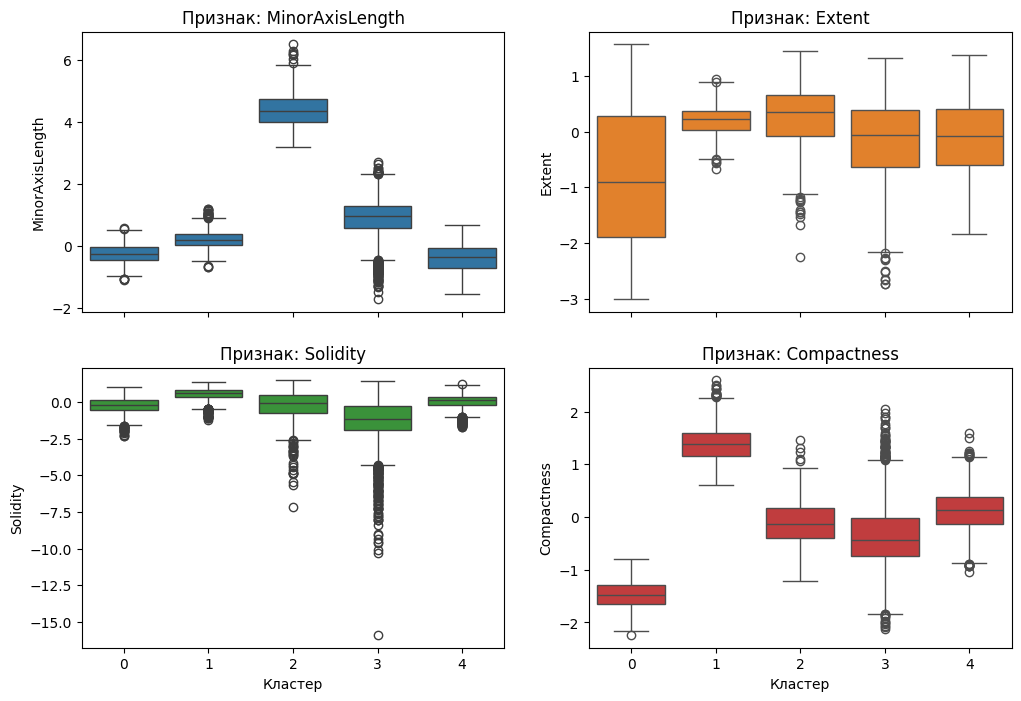

In [54]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_samples,
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
    pairwise_distances,
)
from scipy.stats import f_oneway


# Обучение GMM
k = 5

gmm = GaussianMixture(
    n_components=k,
    covariance_type="full",
    random_state=42,
    n_init=5,
    init_params="kmeans",
)
gmm.fit(X_scaled)
labels = gmm.predict(X_scaled)

# Базовые метрики качества 
sil_samples = silhouette_samples(X_scaled, labels)
sil = silhouette_score(X_scaled, labels)
ch = calinski_harabasz_score(X_scaled, labels)
db = davies_bouldin_score(X_scaled, labels)
ari = adjusted_rand_score(y, labels)

print("Метрики GMM (k = 5):")
print(f"Средний силуэт           : {sil:.4f}")
print(f"Индекс Калински–Харабаса : {ch:.4f}")
print(f"Индекс Дэвиса–Болдина    : {db:.4f}")
print(f"ARI                      : {ari:.4f}")

# Диаграмма силуэта
fig, ax = plt.subplots(figsize=(7, 5))

y_lower = 10
for c in range(k):
    sil_c = sil_samples[labels == c]
    sil_c.sort()
    size_c = sil_c.shape[0]
    y_upper = y_lower + size_c

    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0, sil_c,
        alpha=0.7,
    )
    ax.text(-0.05, y_lower + 0.5 * size_c, str(c))
    y_lower = y_upper + 10

ax.axvline(x=sil, color="red", linestyle="--", label=f"средний силуэт = {sil:.3f}")
ax.set_title("Диаграмма силуэта")
ax.set_xlabel("Silhouette")
ax.set_ylabel("Объекты (по кластерам)")
ax.legend(loc="best")

plt.tight_layout()
plt.show()


# Центры кластеров и внутрикластерные расстояния
centers = gmm.means_      
print("\nЦентры кластеров (в пространстве стандартизованных признаков):")
centers_df = pd.DataFrame(centers, columns=X_scaled.columns)
centers_df.index = [f"cluster_{c}" for c in range(k)]
display(centers_df)

plt.figure(figsize=(10, 4))
sns.heatmap(
    centers_df,
    annot=True,        
    cmap="coolwarm",
    center=0            
)
plt.title("Центры кластеров в пространстве стандартизованных признаков")
plt.xlabel("Признаки")
plt.ylabel("Кластеры")
plt.tight_layout()
plt.show()

# расстояния от объектов до центров
dist_to_centers = pairwise_distances(X_scaled, centers)

cluster_stats = []

for c in range(k):
    mask = (labels == c)
    n_c = mask.sum()
    if n_c == 0:
        mean_dist = np.nan
        std_dist = np.nan
        sse_c = np.nan
    else:
        dists_c = dist_to_centers[mask, c]
        mean_dist = dists_c.mean()
        std_dist = dists_c.std()
        sse_c = (dists_c ** 2).sum()

    cluster_stats.append({
        "cluster": c,
        "size": n_c,
        "mean_dist_to_center": mean_dist,
        "std_dist_to_center": std_dist,
        "within_cluster_SSE": sse_c,
    })

print("\nХарактеристики кластеров (внутрикластерные расстояния / компактность):")
cluster_stats_df = pd.DataFrame(cluster_stats)
display(cluster_stats_df)

# расстояния между центрами кластеров
center_dists = pairwise_distances(centers, centers)
center_dists_df = pd.DataFrame(
    center_dists,
    index=[f"cluster_{c}" for c in range(k)],
    columns=[f"cluster_{c}" for c in range(k)]
)

print("\nРасстояния между центрами кластеров (евклидовы):")
display(center_dists_df)

plt.figure(figsize=(6, 5))
sns.heatmap(center_dists_df, annot=True, fmt=".2f", cmap="Blues")
plt.title("Матрица расстояний между центрами кластеров")
plt.tight_layout()
plt.show()

X_df = X_scaled.copy()
X_df["cluster"] = labels
X_df["class"] = y

feature_cols = [c for c in X_df.columns if c not in ["cluster", "class"]]


# Значимость признаков по кластерам 
anova_rows = []

for feat in feature_cols:
    groups = [X_df.loc[labels == c, feat] for c in range(k) if (labels == c).sum() > 1]
    if len(groups) > 1:
        F, p = f_oneway(*groups)
    else:
        F, p = np.nan, np.nan
    anova_rows.append({
        "feature": feat,
        "F_stat": F,
        "p_value": p,
    })

anova_df = pd.DataFrame(anova_rows)
print("\nЗначимость признаков по кластерам (односторонний ANOVA):")
display(anova_df)


# Boxplot'ы признаков по кластерам
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.ravel()

for i, (feat, color) in enumerate(zip(feature_cols, colors)):
    ax = axes[i]
    sns.boxplot(
        data=X_df,
        x="cluster",
        y=feat,
        ax=ax,
        color=color,
    )
    ax.set_title(f"Признак: {feat}")
    ax.set_xlabel("Кластер")
    ax.set_ylabel(feat)



1. Проанализируем полученные результаты. Значение индекса Калински–Харабаса = 4365.2909, индекса Дэвиса–Болдина = 1.1542, что указывает на умеренно хорошее качество разбиения - межкластерная дисперсия заметно превышает внутрикластерную (высокий CH), однако значение DB больше единицы, то есть кластеры достаточно компактны, но между ними остаётся заметное перекрытие.
Значение среднего силуэта = 0.2687. Такое значение силуэта соответствует удовлетворительной кластерной структуре, значение выше нуля, но далеко до четких разделенных кластеров. 

2. По диаграмме силуэта видно, что среднее значение для 1-ого и 2-ого кластеров значительно выше (~0.55), что характерно для очень хорошо разделенных кластеров. Для кластеров 0 и 4 средние значения уже ниже, примерно равны средним значениям для всех кластеров (~0.27), а кластер 3 показывает худшие значения силуэта – почти половина значений имеют отрицательный силуэт, что свидетельствует о пересечении границ кластеров и неоднозначном отнесении части объектов.

3. Проанализируем кластеры с помощью внутрикластерных расстояний и размеров кластеров.

- Кластер 1 - самая маленькая средняя дистанция до центра (0.59) и небольшой разброс (0.25). Это самый компактный и однородный кластер.
- Кластер 4 - средняя дистанция 0.87, разброс небольшой (0.29), но кластер очень крупный (6012 объектов). Это крупный, довольно плотный кластер, который покрывает большую часть данных.
- Кластер 0 - средняя дистанция 1.22, разброс средний. По компактности хуже, чем 1 и 4, но лучше, чем 2 и 3. Можно считать его умеренно размытым.
- Кластер 2 - небольшой по размеру (523), но среднее расстояние уже 1.30 и достаточно большой разброс (0.76). Это небольшая, но раздутая группа.
- Кластер 3 - самый крупный после 4-го (3581 объектов), при этом самое большое среднее расстояние (1.55) и разброс (0.92). Это наиболее размытый кластер, внутри которого объекты сильно отличаются друг от друга. Именно он больше всего портит силуэт (много отрицательных значений).

4. Кластер 2 наиболее удален от остальных кластеров. Кластеры 0 и 1; 3 и 1 тоже достаточно сильно удалены друг от друга. Ближе всего находятся кластеры 1 и 4 – часть объектов может перекрывать друг друга.

5. По матрице центров кластеров и диаграмм ящиков с усами для признаков:

- Кластер 0 – Самые низкие значения Compactness и Extent – вытянутая/овальная форма фасоли.
- Кластер 1 – Высокое значение Compactness – круглая форма фасоли.
- Кластер 2 – Высокое значение MinorAxisLength – самые крупные фасолины.
- Кластер 3 – Средние положительные значения MinorAxisLength и отрицательные Soldity – средние по размеру фасолины с кривым/неровным краем.
- Кластер 4 – самые маленькие фасолины.


6. Проведем анализ используя метки классов. Значение ARI = 0.5285, что говорит о том, что разбиение существенно лучше случайного, но не идеально.
Для интереса посмотрим и на картинку, представленную в начале работы


Видим, что каждый кластер захватывает 1 – 2 реальных класса. Описанная ранее интерпретация кластеров совпадает с действительными фотографиями:
Например, кластер 2, полностью забравший класс BOMBAY, мы ранее интерпретировали как самые крупные фасолины – фотографии это подтверждают. Остальные соответствия также совпадают. 

В целом и по фотографиями видны внешние совпадения классов CALI и BARBUNYA (кластер 3 – средние фасолины с неровным краем), их различие больше находится в цвете, значения которого, к сожалению, в датасете не представлены.

В целом можно сделать вывод, что сорта фасоли имеют схожие размерные и форменные характеристики, но получается качественно разбить 7 сортов на 5 кластеров, при наличии других важных признаков (например цвета) качество кластеризации могло бы существенно улучшиться.


# Kmeans

## Подбор количества кластеров

Метрики KMeans для разных k:


,k,silhouette,calinski_harabasz,davies_bouldin,ARI,inertia
0,2,0.3804,5126.2524,1.3280,0.1321,35594.8105
1,3,0.3332,4965.7353,1.1831,0.1953,28328.2592
2,4,0.2909,5321.1839,1.1778,0.2455,22548.8077
3,5,0.2875,5215.6286,1.1552,0.2881,19343.3382
4,6,0.2919,5422.4957,1.0558,0.4583,16373.3761
5,7,0.3036,5538.2823,1.0736,0.4867,14234.0664
6,8,0.2935,5433.4345,1.0869,0.4096,12909.0559
7,9,0.3049,5396.5632,1.0639,0.4266,11740.0875
8,10,0.3051,5229.4615,1.0818,0.4292,10986.1317


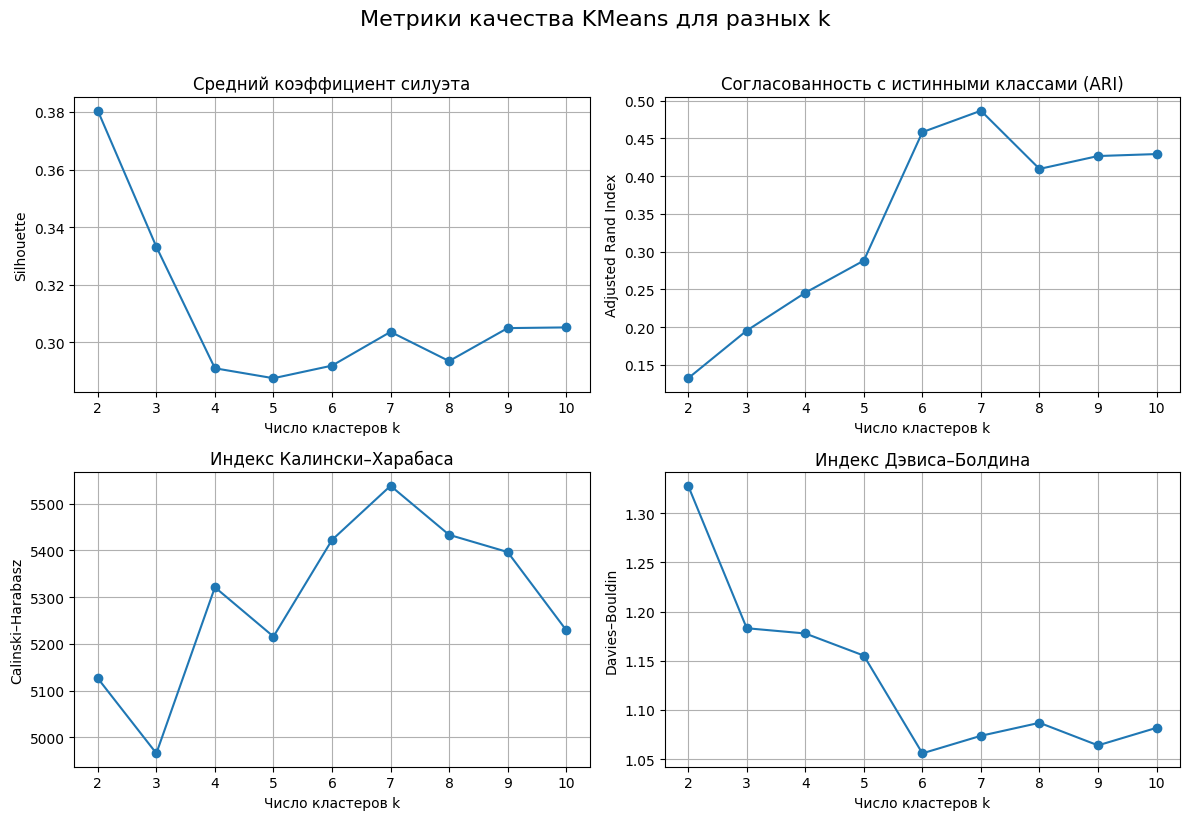

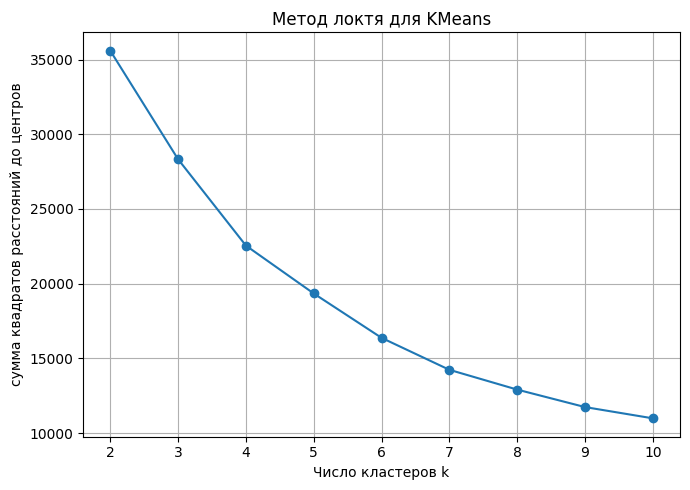

In [55]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
)

k_range = range(2, 11)

rows = []

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        random_state=42,
    )
    kmeans.fit(X_scaled)
    labels = kmeans.labels_

    sil = silhouette_score(X_scaled, labels)
    ch  = calinski_harabasz_score(X_scaled, labels)
    db  = davies_bouldin_score(X_scaled, labels)
    ari = adjusted_rand_score(y, labels)
    inertia = kmeans.inertia_

    rows.append({
        "k": k,
        "silhouette": sil,
        "calinski_harabasz": ch,
        "davies_bouldin": db,
        "ARI": ari,
        "inertia": inertia,
    })

results_km = pd.DataFrame(rows)
print("Метрики KMeans для разных k:")
display(results_km.round(4))

res = results_km.sort_values("k")
k = res["k"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

# 1) Silhouette
axes[0].plot(k, res["silhouette"], marker="o")
axes[0].set_xlabel("Число кластеров k")
axes[0].set_ylabel("Silhouette")
axes[0].set_title("Средний коэффициент силуэта")
axes[0].grid(True)

# 2) ARI
axes[1].plot(k, res["ARI"], marker="o")
axes[1].set_xlabel("Число кластеров k")
axes[1].set_ylabel("Adjusted Rand Index")
axes[1].set_title("Согласованность с истинными классами (ARI)")
axes[1].grid(True)

# 3) Calinski–Harabasz
axes[2].plot(k, res["calinski_harabasz"], marker="o")
axes[2].set_xlabel("Число кластеров k")
axes[2].set_ylabel("Calinski–Harabasz")
axes[2].set_title("Индекс Калински–Харабаса")
axes[2].grid(True)

# 4) Davies–Bouldin
axes[3].plot(k, res["davies_bouldin"], marker="o")
axes[3].set_xlabel("Число кластеров k")
axes[3].set_ylabel("Davies–Bouldin")
axes[3].set_title("Индекс Дэвиса–Болдина")
axes[3].grid(True)

plt.suptitle("Метрики качества KMeans для разных k", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Метод локтя
plt.figure(figsize=(7, 5))
plt.plot(k, res["inertia"], marker="o")
plt.xlabel("Число кластеров k")
plt.ylabel("сумма квадратов расстояний до центров")
plt.title("Метод локтя для KMeans")
plt.grid(True)
plt.tight_layout()
plt.show()


1. Проведем анализ графиков внешних и внутренних метрик. На рисунке представлен график среднего силуэта. На нем видно, что наивысшее значение достигается при k = 2, дальше идет спад до k = 4, и небольшое поднятие при k = 7.
2. По графику индекса Калински–Харабаса наилучшее разбиение достигается при k = 7, а график индекса Дэвиса–Болдина дает лучшее значение при k = 6, значения k = 7 – 10 ненамного хуже.
3. Посмотрим на зависимость значения ARI от количества кластеров. По нему видно, что наивысшее значение достигается при k = 7.
4. Попробуем определить количество кластеров методом локтя. По нему наблюдаем локоть в районе 7 кластеров.

Подводя итог, можно сказать, что лучшим выбором будет k = 7, его средний силуэт несколько хуже, чем при k = 2, при этом остальные метрики значительно лучше.

## Решение

Метрики KMeans (k = 7):
Средний силуэт           : 0.3036
Индекс Калински–Харабаса : 5538.2823
Индекс Дэвиса–Болдина    : 1.0736
ARI                      : 0.4867


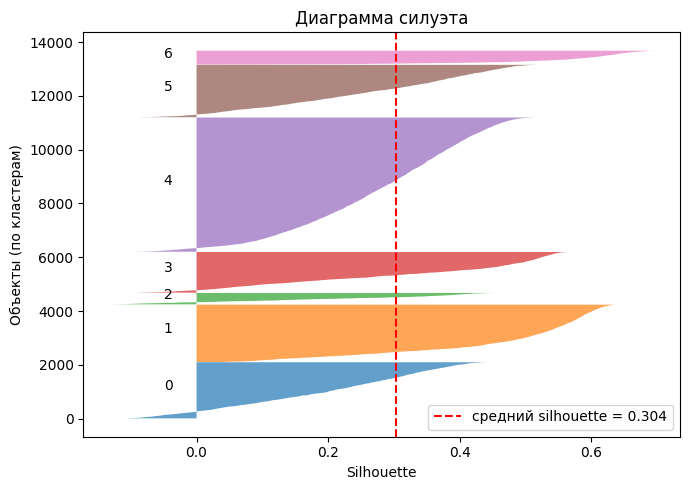


Центры кластеров (в пространстве стандартизованных признаков):


,MinorAxisLength,Extent,Solidity,Compactness
cluster_0,0.419147,0.371498,0.135502,-0.718270
cluster_1,0.209870,0.213768,0.532729,1.313537
cluster_2,0.518357,-0.580828,-4.085365,-0.674053
cluster_3,-0.182113,-1.428813,-0.367171,-1.207684
cluster_4,-0.456360,-0.141360,0.036850,0.182383
cluster_5,1.018837,-0.139994,-1.413195,-0.159301
cluster_6,4.414285,0.257966,-0.238792,-0.109703


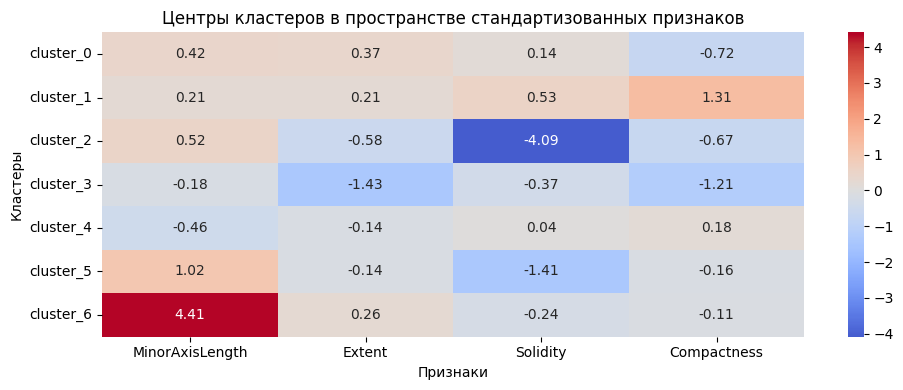


Характеристики кластеров (внутрикластерные расстояния / компактность):


,cluster,size,mean_dist_to_center,std_dist_to_center,within_cluster_SSE
0,0,2087,1.011193,0.319701,2347.292458
1,1,2131,0.640087,0.279469,1039.533106
2,2,426,1.752502,1.047459,1775.753049
3,3,1512,1.023275,0.365323,1784.996979
4,4,4991,0.818909,0.267276,3703.567414
5,5,1949,1.096229,0.383251,2628.421922
6,6,515,1.222518,0.599041,954.501520



Расстояния между центрами кластеров (евклидовы):


,cluster_0,cluster_1,cluster_2,cluster_3,cluster_4,cluster_5,cluster_6
cluster_0,0.000000,2.086793,4.328330,2.023570,1.360310,1.825420,4.060106
cluster_1,2.086793,0.000000,5.099397,3.165138,1.447544,2.595273,4.505542
cluster_2,4.328330,5.099397,0.000000,3.914008,4.343886,2.801835,5.567445
cluster_3,2.023570,3.165138,3.914008,0.000000,1.956595,2.301436,5.019376
cluster_4,1.360310,1.447544,4.343886,1.956595,0.000000,2.096565,4.903462
cluster_5,1.825420,2.595273,2.801835,2.301436,2.096565,0.000000,3.615124
cluster_6,4.060106,4.505542,5.567445,5.019376,4.903462,3.615124,0.000000


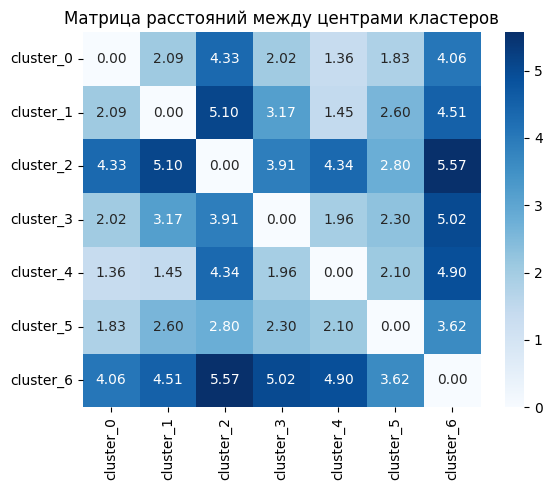


Значимость признаков по кластерам (односторонний ANOVA, KMeans):


,feature,F_stat,p_value
0,MinorAxisLength,8941.211815,0.0
1,Extent,2215.777789,0.0
2,Solidity,5285.579682,0.0
3,Compactness,6231.441362,0.0


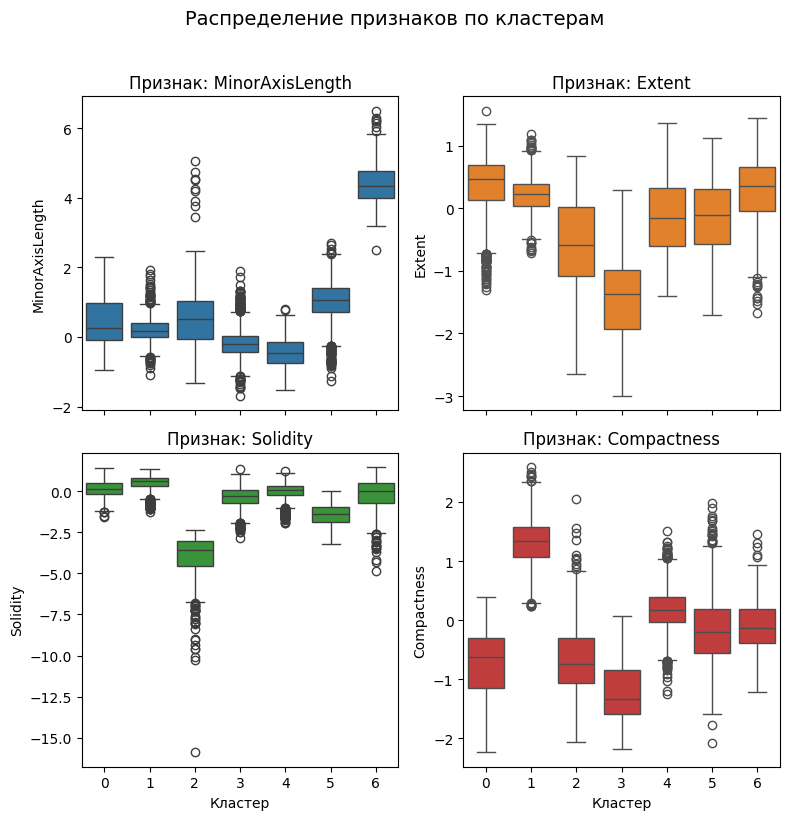

In [56]:
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_samples,
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
    pairwise_distances,
)
from scipy.stats import f_oneway
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

k = 7  

kmeans = KMeans(
    n_clusters=k,
    init="k-means++",
    n_init=10,
    random_state=42,
)
kmeans.fit(X_scaled)
labels = kmeans.labels_


sil_samples = silhouette_samples(X_scaled, labels)
sil = silhouette_score(X_scaled, labels)
ch = calinski_harabasz_score(X_scaled, labels)
db = davies_bouldin_score(X_scaled, labels)
ari = adjusted_rand_score(y, labels)

print(f"Метрики KMeans (k = {k}):")
print(f"Средний силуэт           : {sil:.4f}")
print(f"Индекс Калински–Харабаса : {ch:.4f}")
print(f"Индекс Дэвиса–Болдина    : {db:.4f}")
print(f"ARI                      : {ari:.4f}")


# Диаграмма силуэта
fig, ax = plt.subplots(figsize=(7, 5))

y_lower = 10
for c in range(k):
    sil_c = sil_samples[labels == c]
    sil_c.sort()
    size_c = sil_c.shape[0]
    y_upper = y_lower + size_c

    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0, sil_c,
        alpha=0.7,
    )
    ax.text(-0.05, y_lower + 0.5 * size_c, str(c))
    y_lower = y_upper + 10

ax.axvline(x=sil, color="red", linestyle="--",
           label=f"средний silhouette = {sil:.3f}")
ax.set_title(f"Диаграмма силуэта")
ax.set_xlabel("Silhouette")
ax.set_ylabel("Объекты (по кластерам)")
ax.legend(loc="best")

plt.tight_layout()
plt.show()


# Центры кластеров и внутрикластерные расстояния
centers = kmeans.cluster_centers_ 

print("\nЦентры кластеров (в пространстве стандартизованных признаков):")
centers_df = pd.DataFrame(centers, columns=X_scaled.columns)
centers_df.index = [f"cluster_{c}" for c in range(k)]
display(centers_df)

plt.figure(figsize=(10, 4))
sns.heatmap(
    centers_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Центры кластеров в пространстве стандартизованных признаков")
plt.xlabel("Признаки")
plt.ylabel("Кластеры")
plt.tight_layout()
plt.show()

# расстояния от объектов до центров
dist_to_centers = pairwise_distances(X_scaled, centers)

cluster_stats = []
for c in range(k):
    mask = (labels == c)
    n_c = mask.sum()
    if n_c == 0:
        mean_dist = np.nan
        std_dist = np.nan
        sse_c = np.nan
    else:
        dists_c = dist_to_centers[mask, c]
        mean_dist = dists_c.mean()
        std_dist = dists_c.std()
        sse_c = (dists_c ** 2).sum()

    cluster_stats.append({
        "cluster": c,
        "size": n_c,
        "mean_dist_to_center": mean_dist,
        "std_dist_to_center": std_dist,
        "within_cluster_SSE": sse_c,
    })

print("\nХарактеристики кластеров (внутрикластерные расстояния / компактность):")
cluster_stats_df = pd.DataFrame(cluster_stats)
display(cluster_stats_df)

# расстояния между центрами кластеров
center_dists = pairwise_distances(centers, centers)
center_dists_df = pd.DataFrame(
    center_dists,
    index=[f"cluster_{c}" for c in range(k)],
    columns=[f"cluster_{c}" for c in range(k)]
)

print("\nРасстояния между центрами кластеров (евклидовы):")
display(center_dists_df)

plt.figure(figsize=(6, 5))
sns.heatmap(center_dists_df, annot=True, fmt=".2f", cmap="Blues")
plt.title("Матрица расстояний между центрами кластеров")
plt.tight_layout()
plt.show()


X_df = X_scaled.copy()
X_df["cluster"] = labels
X_df["class"] = y

feature_cols = [c for c in X_df.columns if c not in ["cluster", "class"]]


# Значимость признаков по кластерам
anova_rows = []
for feat in feature_cols:
    groups = [X_df.loc[labels == c, feat] for c in range(k) if (labels == c).sum() > 1]
    if len(groups) > 1:
        F, p = f_oneway(*groups)
    else:
        F, p = np.nan, np.nan
    anova_rows.append({
        "feature": feat,
        "F_stat": F,
        "p_value": p,
    })

anova_df = pd.DataFrame(anova_rows)
print("\nЗначимость признаков по кластерам (односторонний ANOVA, KMeans):")
display(anova_df)


# Boxplot'ы признаков по кластерам
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red",
          "tab:purple", "tab:brown", "tab:pink", "tab:gray"]

n_feats = len(feature_cols)
n_rows = 2
n_cols = int(np.ceil(n_feats / n_rows))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows), sharex=True)
axes = np.array(axes).ravel()

for i, feat in enumerate(feature_cols):
    ax = axes[i]
    sns.boxplot(
        data=X_df,
        x="cluster",
        y=feat,
        ax=ax,
        color=colors[i % len(colors)],
    )
    ax.set_title(f"Признак: {feat}")
    ax.set_xlabel("Кластер")
    ax.set_ylabel(feat)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Распределение признаков по кластерам", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


Проанализируем полученные результаты. 
1. Значение индекса Калински–Харабаса = 5538.2823, индекса Дэвиса–Болдина = 1.0736, что указывает на достаточно хорошую кластерную структуру. Высокий CH говорит о том, что центры кластеров достаточно хорошо разнесены, а сами кластеры достаточно компактны. Значение DB немного больше 1, что характерно для среднего по качеству разбиения - кластеры различимы, но между ними всё ещё есть заметное перекрытие.

2. Значение среднего силуэта = 0.3036. Такое значение силуэта показывает умеренно хорошее качество кластеризации. По силуэт-диаграмме видим наибольшие значения силуэта у 6 (~0.6), 1 (~0.5) и 3 (~0.4) кластеров. Кластеры 5, 4 средние по силуэту, хуже всего себя показывают кластеры 2 и 0 (много отрицательных значений и в целом виден низкий средний силуэт).

3. Проанализируем кластеры с помощью таблицы внутрикластерных расстояния и размер кластеров.
Самыми удачными с этой точки зрения выглядят кластеры 1 и 4. В них объекты располагаются ближе к центру, чем в остальных, а разброс расстояний относительно небольшой. Особенно интересен кластер 4 - при самом большом количестве объектов он остаётся достаточно плотным — большая группа точек хорошо сгруппирована вокруг своего центра.
Кластеры 0, 3 и 5 можно отнести к среднему уровню качества. Объекты в них уже заметно дальше от центров и разброс больше. Это нормальные, умеренно компактные группы.
Кластер 6 - при небольшом количестве объектов они находятся довольно далеко от центра, а разброс расстояний ощутимо выше. 
Наиболее слабым по структуре оказался кластер 2. Здесь расстояния до центра максимальны, а разброс самый высокий среди всех кластеров. По сути, это самая размытая группа, в которой могут смешиваться несколько подгрупп. 

4. На рисунке представлены расстояния между кластерами. Тут выделятся кластеры 2 и 6 (особенно 6) как самые удаленные от остальных кластеров. Кластер 4 ближе всего к остальным кластерам, кластеры 0, 1, 3, 5 примерно на одинаковом удалении от остальных кластеров. 

5. По центрам классов и ящикам с усами можно сделать такие выводы:
- Кластер 0 – Среднего размера, вытянутой, близкой к овалу форме.
- Кластер 1 – Круглые фасолины.
- Кластер 2 – Небольшие фасолины с очень выпуклой/изогнутой формой.
- Кластер 3 – Самые вытянутые фасолины.
- Кластер 4 – Самые маленькие.
- Кластер 5 – Больше среднего с выпуклой/изогнутой формой.
- Кластер 6 – Самые большие фасолины.

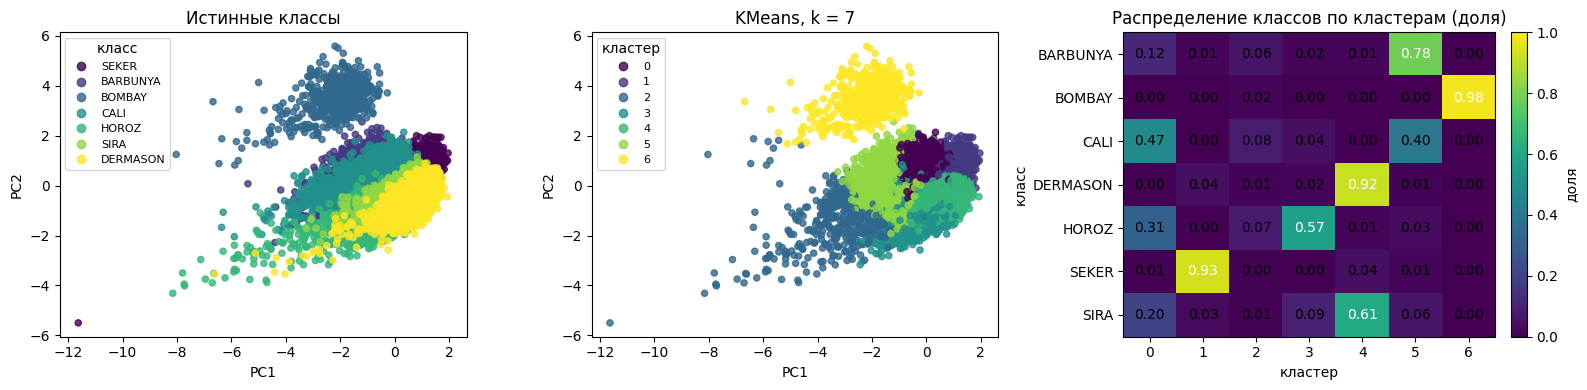

In [57]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

k = 7
kmeans = KMeans(
    n_clusters=k,
    init="k-means++",
    n_init=10,
    random_state=42,
)
kmeans.fit(X_scaled)
km_labels = kmeans.labels_

X_pca = PCA(n_components=2, random_state=42).fit_transform(X_scaled)

y_codes, y_classes = pd.factorize(y)

cm_counts = pd.crosstab(
    pd.Series(y, name="class"),
    pd.Series(km_labels, name="cluster"),
)
cm = cm_counts.div(cm_counts.sum(axis=1), axis=0) 

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4))

sc1 = ax1.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=y_codes, s=20, alpha=0.8
)
ax1.set_title("Истинные классы")
ax1.set_xlabel("PC1")
ax1.set_ylabel("PC2")
handles1, _ = sc1.legend_elements()
ax1.legend(handles1, y_classes.astype(str),
           title="класс", loc="best", fontsize=8)

sc2 = ax2.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=km_labels, s=20, alpha=0.8
)
ax2.set_title(f"KMeans, k = {k}")
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
handles2, _ = sc2.legend_elements()
ax2.legend(handles2, sorted(np.unique(km_labels)),
           title="кластер", loc="best", fontsize=8)

im = ax3.imshow(cm.values, vmin=0, vmax=1, aspect="auto", cmap="viridis")
ax3.set_title("Распределение классов по кластерам (доля)")
ax3.set_xlabel("кластер")
ax3.set_ylabel("класс")

ax3.set_xticks(np.arange(cm.shape[1]))
ax3.set_yticks(np.arange(cm.shape[0]))
ax3.set_xticklabels(cm.columns)
ax3.set_yticklabels(cm.index)

for (i, j), v in np.ndenumerate(cm.values):
    ax3.text(j, i, f"{v:.2f}", ha="center", va="center", color="white" if v > 0.5 else "black")

cbar = fig.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)
cbar.set_label("доля", rotation=90)

plt.tight_layout()
plt.show()


Теперь перейдем к анализу с использованием реальных меток классов. Значение ARI = 0.4867, распределение явно лучше случайного, но далеко не идеальное.
Видим очень удачные кластеры 1 и 6 – они полностью забирают по классу, 0-ой кластер сочетает в себе сразу 3 сорта, 4 и 5 кластеры по 1 целому классу и половине другого, 2 кластер не содержит в себе какого-то доминирующего класса, по сути переходный кластер. В целом сопоставление с метками классами не очень удачное. 

# Сравнительный анализ решений
Сравним решение методами GMM и k-средних. Сравним основные метрики.
|Метрика| GMM (k = 5)|k-средних (k = 7)|
|-|-|-|
|Средний силуэт|  0.2687| 0.3036|
|Индекс Калински–Харабаса| 4365.2909| 5538.2823|
|Индекс Дэвиса–Болдина| 1.1542| 1.0736|
|ARI| 0.5285| 0.4867|


Видим, что у метода k-средних показатели внутренних метрик лучше, даёт более компактные и лучше разделённые кластеры в признаковом пространстве.

При этом GMM лучше по внешней метрике, а также анализ показал хорошую интерпретируемость кластеров – каждый кластер почти полностью забрал 1 – 2 класса. 

Для данного датасета в прикладной задаче лучше использовать GMM как более интерпретируемую модель, несмотря на то что значения внутренних метрик несколько хуже.

Интерпретация всех полученных результатов каждого из методов приведена ранее. 


# Результаты исследования влияния параметров алгоритма на качество решения

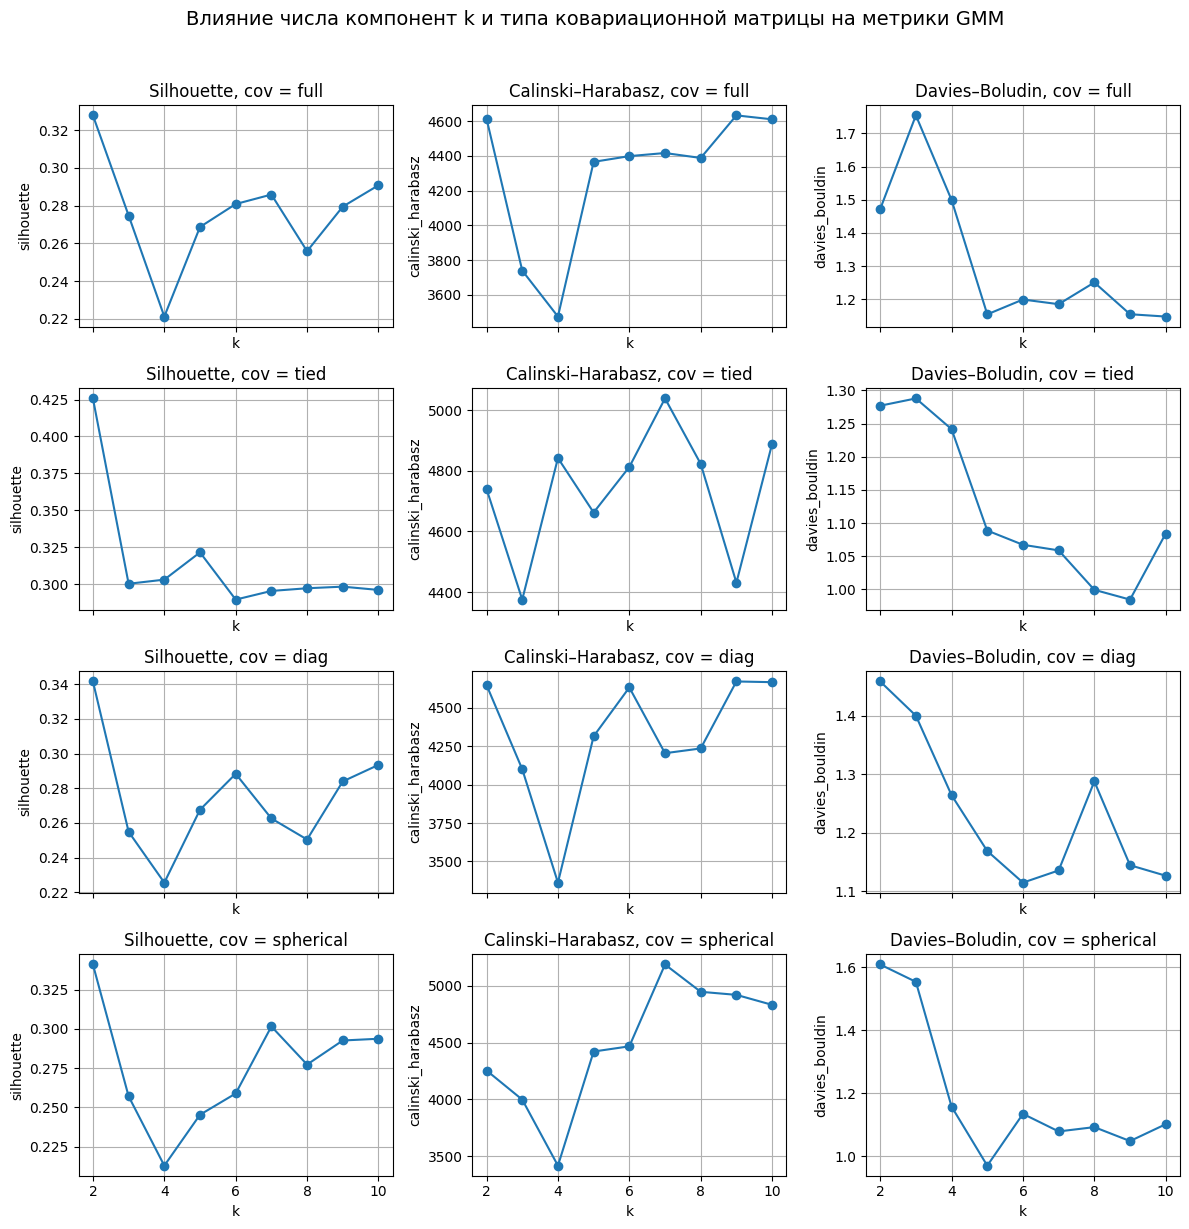

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
)

X_arr = np.asarray(X_scaled)
y_arr = np.asarray(y)

k_values = range(2, 11) 
cov_types = ["full", "tied", "diag", "spherical"]

rows = []

for cov in cov_types:
    for k in k_values:
        gmm = GaussianMixture(
            n_components=k,
            covariance_type=cov,
            random_state=42,
            n_init=5,
            init_params="kmeans",
        )

        labels = gmm.fit_predict(X_arr)

        sil = silhouette_score(X_arr, labels)
        ch  = calinski_harabasz_score(X_arr, labels)
        db  = davies_bouldin_score(X_arr, labels)

        rows.append({
            "k": k,
            "covariance_type": cov,
            "silhouette": sil,
            "calinski_harabasz": ch,
            "davies_bouldin": db,
        })

results_gmm = pd.DataFrame(rows)
metrics = [
    ("silhouette", "Silhouette"),
    ("calinski_harabasz", "Calinski–Harabasz"),
    ("davies_bouldin", "Davies–Boludin"),
]

n_rows = len(cov_types)
n_cols = len(metrics)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), sharex=True)
axes = np.array(axes)

for i, cov in enumerate(cov_types):
    df_cov = results_gmm[results_gmm["covariance_type"] == cov].sort_values("k")

    for j, (metric, title) in enumerate(metrics):
        ax = axes[i, j]

        ax.plot(df_cov["k"], df_cov[metric], marker="o")
        ax.set_title(f"{title}, cov = {cov}")
        ax.set_xlabel("k")
        ax.set_ylabel(metric)
        ax.grid(True)

plt.suptitle(
    "Влияние числа компонент k и типа ковариационной матрицы на метрики GMM",
    y=1.02,
    fontsize=14,
)
plt.tight_layout()
plt.show()


Для метода GMM было проведено исследование влияния типа ковариационной матрицы (cov) и количества кластеров на метрики. 

Во всех типах ковариаций силуэт максимален при малом числе компонент (k=2–3) и постепенно снижается по мере роста k. 

Тип tied даёт самые высокие значения силуэта вообще (при k≈2 силуэт≈0.4+), то есть кластеры получаются наиболее отделёнными при общей ковариационной матрице. Однако по мере роста k разница между tied, full, diag и spherical сильно уменьшается – для k≈5–7 кривые силуэта уже довольно близки.

По индексу Калински–Харабаса (CH) для всех ковариаций наблюдается максимум в области k≈5–7. Это логично: при слишком малом числе компонент внутри кластеров высокая внутрикластерная вариация, при слишком большом – кластеры становятся слишком мелкими. Пик CH в районе 5–7 говорит, что именно там достигается хороший компромисс между компактностью внутри кластеров и разбросом между ними.

Индекс Дэвиса–Болдина (DB) во всех вариантах монотонно или почти монотонно снижается при росте k (чем меньше DB – тем лучше). Особенно хорошо это видно для full и diag: при k=2 значения DB максимальны, а к k≈7–10 падают к ≈1.1–1.2. Это ещё раз показывает, что слишком грубое разбиение (2–3 кластера) даёт размазанные группы.

# Заключение

В результате работы были изучены методы кластеризации, проведен анализ и отбор пристроены диаграммы распределения, для каждого метода были проанализированы результаты, приведена интерпретация кластеров, а также проведено сравнение между ними. Для GMM было проведено исследование по влиянию значения параметров на качество кластеризации